# Dashboard GAC Motor · Etapa I y Etapa II

**Etapa I · Extracción de características:** análisis univariado de 15 variables (vistas *Hallazgos principales*, *Análisis univariado* y *Comparación por periodo* del dashboard).  
**Etapa II · Modelado predictivo:** a) análisis de correlaciones, regresión lineal simple y regresión lineal múltiple, superponiendo la dispersión de los datos predichos (en este notebook y en el menú *Etapa II* del dashboard).

Corre las celdas en orden, de arriba hacia abajo. Este notebook tiene que estar en la **misma carpeta** que los archivos `_Limpio.csv` y `_Mensual.csv`.

In [ ]:
#Instalamos las librerias (solo la primera vez)
#SCIPY: p-valores de la regresión · MATPLOTLIB: gráficas estáticas del notebook
%pip install streamlit plotly pandas scipy matplotlib

In [ ]:
#Revisamos que los 13 CSV esten en la carpeta antes de crear la app
import os
archivos = ["Analisis_de_Piso_Limpio.csv", "Funnel_Limpio.csv", "Leads_Reales_Limpio.csv",
            "Marketing_Limpio.csv", "MKT_Digital_Limpio.csv", "Principales_Canales_Limpio.csv",
            "SDC_Limpio.csv", "TOPS_TDH_Limpio.csv", "Ventas_Limpio.csv",
            "Ventas_por_Asesor_Limpio.csv",
            #Bases nuevas de la Etapa II
            "Funnel_Ventas_Mensual.csv", "MKT_Digital_Mensual.csv", "Ventas_por_Asesor_Mensual.csv"]
archivos += ["logo_gac.png", "auto fondo.jpeg", "disco_freno.png", "fibra_carbono.png", "brillo_dona.png"]
#Acepta también los archivos descargados como "nombre (1).csv"
for archivo in archivos:
    base, ext = os.path.splitext(archivo)
    hay = any(os.path.exists(v) for v in [archivo, f"{base} (1){ext}", f"{base} 1{ext}", f"{base}_1{ext}"])
    print("OK   " if hay else "FALTA", archivo)

---
# Etapa II · Modelado predictivo

En esta sección se hace el análisis **en el notebook** (con gráficas estáticas que se ven en GitHub). El dashboard repite estos mismos modelos de forma interactiva en el menú **Etapa II** (cualquier base, cualquier Y y cualquier X).

Base usada aquí: **Mensual combinada** = una fila por mes uniendo Marketing, Leads reales, SDC, Principales canales, TOPS/TDH y las 3 bases `_Mensual`. Variable a predecir: **Ventas**.

In [1]:
#Librerías del análisis (matplotlib solo se usa en el notebook para gráficas estáticas)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#Colores GAC: rojo = acento (predicción), carbón = datos reales, gris = contexto
ROJO, CARBON, GRIS = "#C8102E", "#2F3640", "#9AA1AB"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

#Lee un CSV aunque se haya descargado como "nombre (1).csv" o "nombre 1.csv"
def leer(nombre):
    base = nombre[:-4]
    for variante in [nombre, f"{base} (1).csv", f"{base} 1.csv", f"{base}_1.csv"]:
        if os.path.exists(variante):
            return pd.read_csv(variante)
    raise FileNotFoundError(f"Falta {nombre} en esta carpeta")

#Unimos todas las bases mensuales por Año y Mes (una fila por mes)
k = ["Año", "Mes"]
Mensual = leer("Marketing_Limpio.csv")[k + ["Leads_Total", "Ventas", "Provision", "Reembolso_Total",
                                             "Bono_Marketing", "Aportacion_Agencia"]]
piezas = [leer("Leads_Reales_Limpio.csv")[k + ["Efectivos", "No_Contesta", "Ilocalizable", "Abiertos"]],
          leer("SDC_Limpio.csv")[k + ["Generadas", "Aprobadas", "Rechazadas", "Formalizadas"]],
          leer("Principales_Canales_Limpio.csv").groupby(k, as_index=False)[["Citas_Programadas", "Citas_Efectivas", "PDM"]].sum(),
          leer("Funnel_Ventas_Mensual.csv")[k + ["Objetivo"]].rename(columns={"Objetivo": "Objetivo_Ventas"}),
          leer("Ventas_por_Asesor_Mensual.csv"),
          leer("MKT_Digital_Mensual.csv"),
          leer("TOPS_TDH_Limpio.csv")[k + ["Plantilla", "Operando", "Bajas", "Vacantes", "Productividad_APVS"]]]
for p in piezas:
    Mensual = Mensual.merge(p, on=k, how="left")

#Etiqueta de periodo (2025-03) para ordenar y para identificar cada punto
MESES = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto",
         "Septiembre", "Octubre", "Noviembre", "Diciembre"]
Mensual["Periodo"] = Mensual["Año"].astype(str) + "-" + Mensual["Mes"].map({m: f"{i:02d}" for i, m in enumerate(MESES, 1)})
Mensual = Mensual.sort_values("Periodo").reset_index(drop=True)
print(f"Base mensual combinada: {Mensual.shape[0]} meses x {Mensual.shape[1]} columnas")
Mensual.head()

Base mensual combinada: 29 meses x 28 columnas


,Año,Mes,Leads_Total,Ventas,Provision,Reembolso_Total,Bono_Marketing,Aportacion_Agencia,Efectivos,No_Contesta,...,PDM,Objetivo_Ventas,Ventas_Asesores,Leads_Digitales,Plantilla,Operando,Bajas,Vacantes,Productividad_APVS,Periodo
0,2024,Febrero,543,12,0.0,0.0,0.0,0.0,389.0,33.0,...,22,NaN,7.53,NaN,NaN,NaN,NaN,NaN,NaN,2024-02
1,2024,Marzo,178,7,0.0,0.0,0.0,0.0,128.0,13.0,...,13,NaN,7.00,NaN,NaN,NaN,NaN,NaN,NaN,2024-03
2,2024,Abril,416,8,0.0,0.0,0.0,0.0,288.0,46.0,...,36,NaN,8.00,NaN,NaN,NaN,NaN,NaN,NaN,2024-04
3,2024,Mayo,422,13,0.0,0.0,0.0,0.0,274.0,100.0,...,51,NaN,8.53,NaN,NaN,NaN,NaN,NaN,NaN,2024-05
4,2024,Junio,967,6,0.0,0.0,0.0,0.0,620.0,173.0,...,33,NaN,6.00,NaN,NaN,NaN,NaN,NaN,NaN,2024-06


## a) Análisis de correlaciones
Antes de modelar vemos qué variables se mueven junto con **Ventas**. r cerca de 1 = relación fuerte y positiva; cerca de 0 = no hay relación.

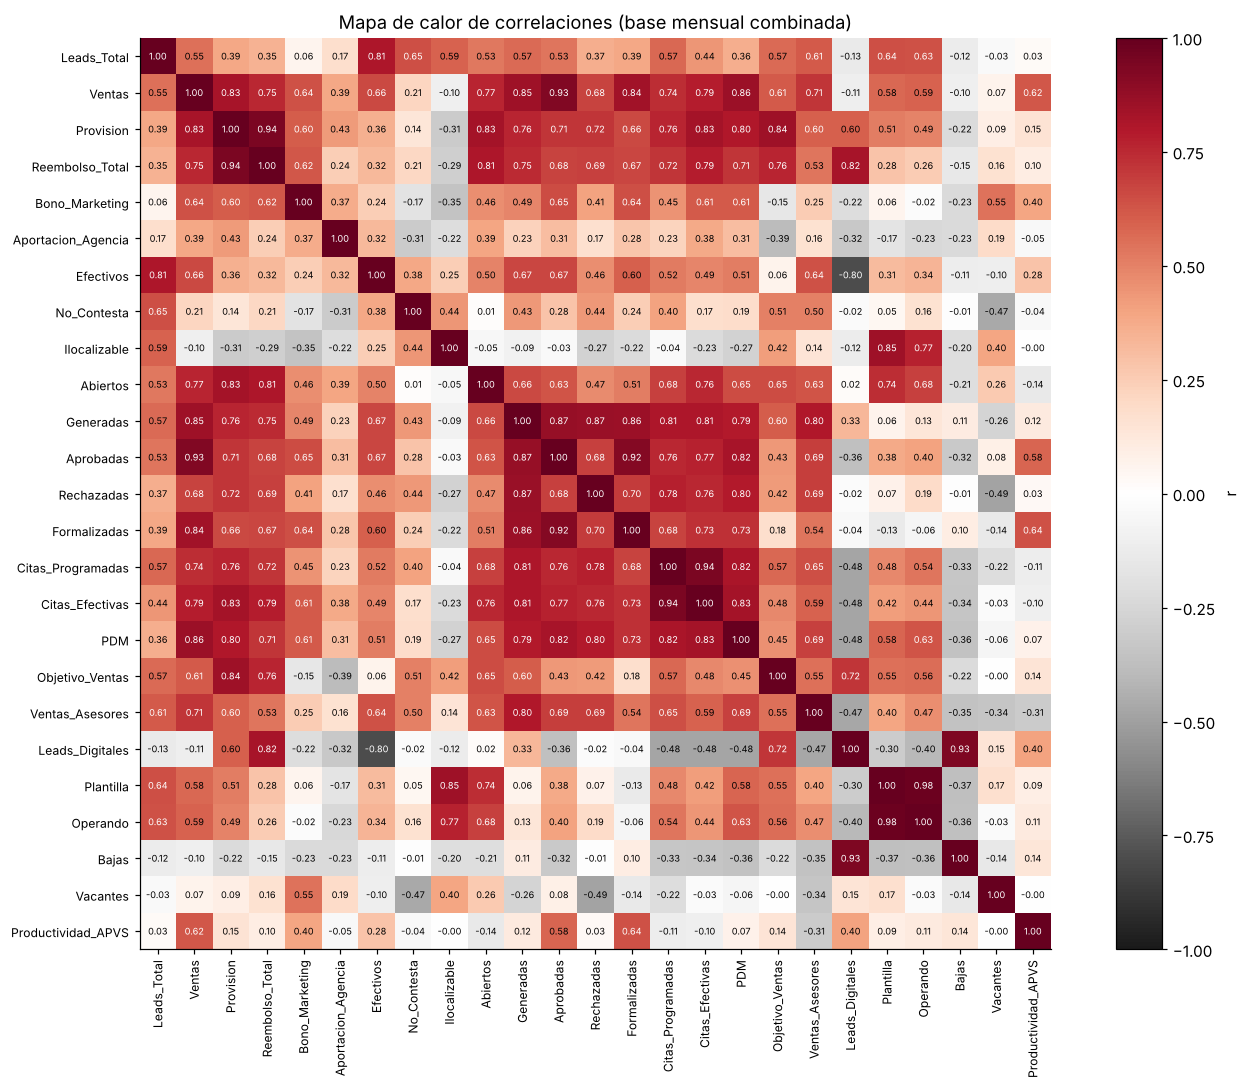

,r con Ventas
Aprobadas,0.93
PDM,0.86
Generadas,0.85
Formalizadas,0.84
Provision,0.83
Citas_Efectivas,0.79
Abiertos,0.77
Reembolso_Total,0.75
Citas_Programadas,0.74
Ventas_Asesores,0.71


In [2]:
#Matriz de correlación de Pearson (solo numéricas y sin el año)
numericas = [c for c in Mensual.select_dtypes("number").columns if c != "Año" and Mensual[c].nunique() > 1]
Matriz = Mensual[numericas].corr()

#HEATMAP de correlaciones
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(Matriz, cmap="RdGy_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas)), numericas, rotation=90, fontsize=8)
ax.set_yticks(range(len(numericas)), numericas, fontsize=8)
for i in range(len(numericas)):
    for j in range(len(numericas)):
        ax.text(j, i, f"{Matriz.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(Matriz.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="r")
ax.set_title("Mapa de calor de correlaciones (base mensual combinada)")
plt.tight_layout()
plt.show()

#Ranking: correlación de cada variable con Ventas
Corr_Ventas = Matriz["Ventas"].drop("Ventas").sort_values(key=abs, ascending=False).round(2)
Corr_Ventas.to_frame("r con Ventas")

## b) Regresión lineal simple
Modelo: **Ventas = b₀ + b₁ · X**. Se ajusta por mínimos cuadrados ordinarios (OLS). En la gráfica se **superpone la dispersión de los datos predichos** (rombos rojos) sobre los datos reales (puntos carbón); las líneas punteadas son el error de cada mes.

Ecuación: Ventas = 10.808 + 0.1424 x Citas_Efectivas
R² = 0.616 | r = 0.785 | p-valor de b1 = 0.0000 | n = 29


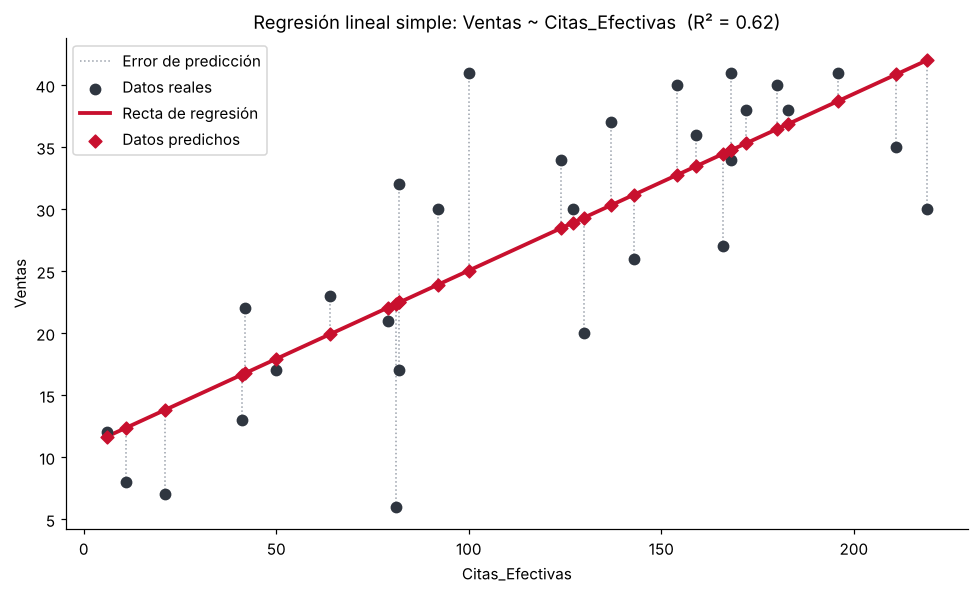

In [3]:
#Función OLS: regresa coeficientes, predicciones, R², R² ajustado, errores estándar y p-valores
def ols(df, y, xs):
    d = df.dropna(subset=[y] + xs)
    X = np.column_stack([np.ones(len(d))] + [d[x].to_numpy(float) for x in xs])
    Y = d[y].to_numpy(float)
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    pred = X @ beta
    res = Y - pred
    n, kk = X.shape
    gl = n - kk
    r2 = 1 - (res ** 2).sum() / ((Y - Y.mean()) ** 2).sum()
    se = np.sqrt(np.diag((res ** 2).sum() / gl * np.linalg.inv(X.T @ X)))
    t = beta / se
    return {"d": d, "beta": beta, "pred": pred, "res": res, "r2": r2,
            "r2a": 1 - (1 - r2) * (n - 1) / gl, "se": se, "t": t,
            "p": 2 * stats.t.sf(np.abs(t), gl), "n": n, "rmse": np.sqrt((res ** 2).mean())}

#Regresión lineal simple: Ventas explicadas por Citas efectivas
Y, X1 = "Ventas", "Citas_Efectivas"
RLS = ols(Mensual, Y, [X1])
b0, b1 = RLS["beta"]
print(f"Ecuación: {Y} = {b0:.3f} + {b1:.4f} x {X1}")
print(f"R² = {RLS['r2']:.3f} | r = {np.sqrt(RLS['r2']):.3f} | p-valor de b1 = {RLS['p'][1]:.4f} | n = {RLS['n']}")

#GRÁFICA: dispersión real + recta + dispersión de los datos predichos
d = RLS["d"]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.vlines(d[X1], d[Y], RLS["pred"], colors=GRIS, linestyles="dotted", linewidth=1, label="Error de predicción")
ax.scatter(d[X1], d[Y], color=CARBON, s=45, label="Datos reales", zorder=3)
xs = np.linspace(d[X1].min(), d[X1].max(), 50)
ax.plot(xs, b0 + b1 * xs, color=ROJO, linewidth=2.5, label="Recta de regresión")
ax.scatter(d[X1], RLS["pred"], color=ROJO, marker="D", s=35, label="Datos predichos", zorder=4)
ax.set_xlabel(X1)
ax.set_ylabel(Y)
ax.set_title(f"Regresión lineal simple: {Y} ~ {X1}  (R² = {RLS['r2']:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

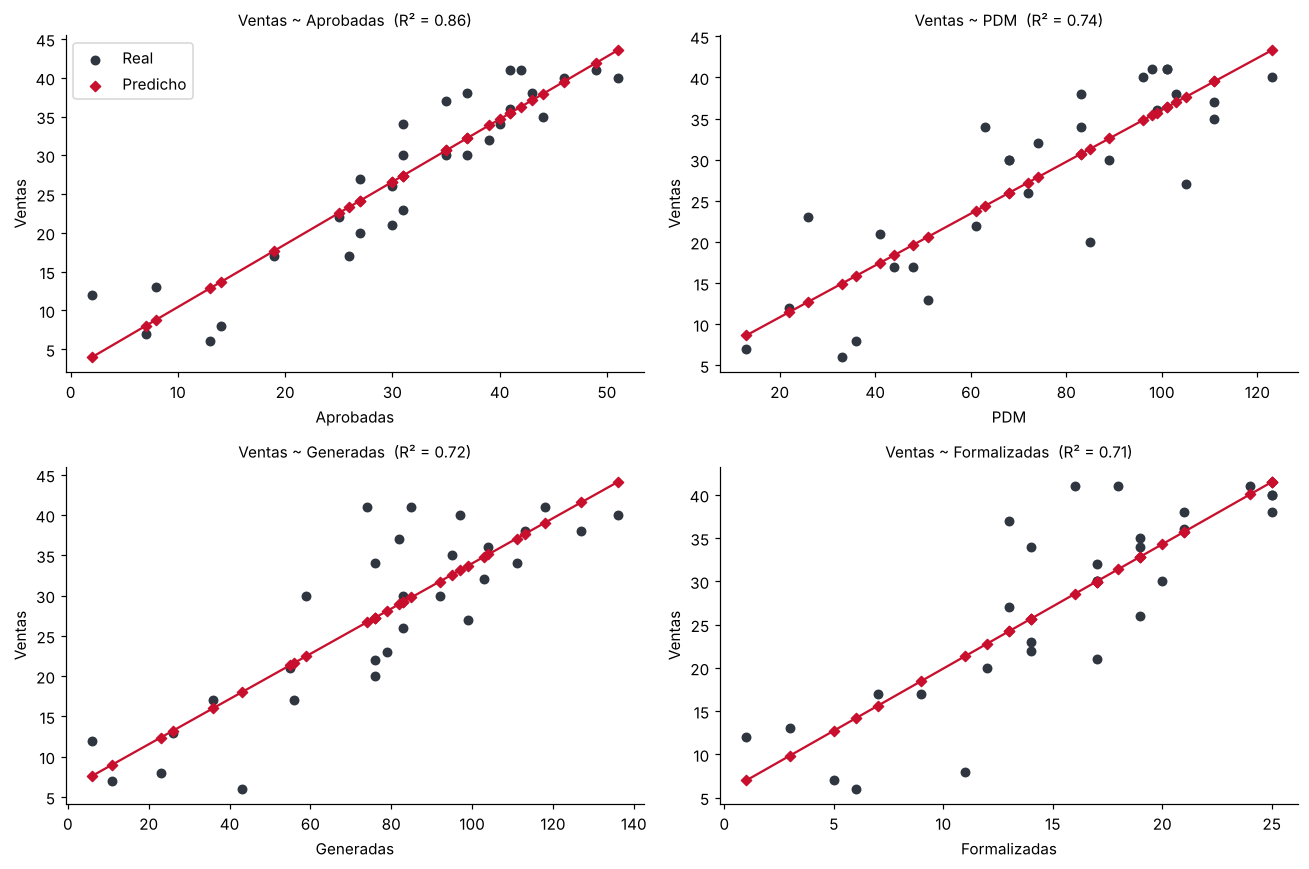

,X,b0,b1,R²,p-valor b1,n
0,Aprobadas,2.3635,0.8074,0.8606,0.0000,29
1,PDM,4.5375,0.3152,0.7352,0.0000,29
2,Generadas,5.9234,0.2807,0.7216,0.0000,29
3,Formalizadas,5.5343,1.4378,0.7116,0.0000,29
4,Provision,17.4715,0.0000,0.6833,0.0000,29
5,Citas_Efectivas,10.8082,0.1424,0.6163,0.0000,29
6,Abiertos,17.9878,0.0365,0.5861,0.0000,28
7,Reembolso_Total,19.3982,0.0000,0.5665,0.0000,29
8,Citas_Programadas,8.7311,0.1088,0.5456,0.0000,29
9,Ventas_Asesores,8.6950,0.9935,0.5112,0.0000,29


In [4]:
#Regresión lineal simple con CADA variable posible: ¿cuál X sola predice mejor las ventas?
filas = []
for x in [c for c in numericas if c != Y]:
    m = ols(Mensual, Y, [x])
    filas.append({"X": x, "b0": m["beta"][0], "b1": m["beta"][1], "R²": m["r2"], "p-valor b1": m["p"][1], "n": m["n"]})
Ranking_RLS = pd.DataFrame(filas).sort_values("R²", ascending=False).reset_index(drop=True)

#Las 4 mejores regresiones simples, cada una con su dispersión predicha superpuesta
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, x in zip(axes.flat, Ranking_RLS["X"].head(4)):
    m = ols(Mensual, Y, [x])
    ax.scatter(m["d"][x], m["d"][Y], color=CARBON, s=30, label="Real")
    ax.scatter(m["d"][x], m["pred"], color=ROJO, marker="D", s=22, label="Predicho")
    xx = np.linspace(m["d"][x].min(), m["d"][x].max(), 50)
    ax.plot(xx, m["beta"][0] + m["beta"][1] * xx, color=ROJO)
    ax.set_title(f"{Y} ~ {x}  (R² = {m['r2']:.2f})", fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(Y)
axes.flat[0].legend()
plt.tight_layout()
plt.show()
Ranking_RLS.round(4)

## c) Regresión lineal múltiple
Modelo: **Ventas = b₀ + b₁·Leads + b₂·Citas efectivas + b₃·Pruebas de manejo + b₄·Solicitudes de crédito aprobadas**. Cada X es un paso del embudo de venta. Se revisa el R² ajustado, la significancia de cada coeficiente (p < 0.05) y el VIF (multicolinealidad: mayor a 10 es problema).

In [5]:
#Regresión lineal múltiple
XS = ["Leads_Total", "Citas_Efectivas", "PDM", "Aprobadas"]
RLM = ols(Mensual, Y, XS)
print(f"R² = {RLM['r2']:.3f} | R² ajustado = {RLM['r2a']:.3f} | error típico = {RLM['rmse']:.2f} ventas | n = {RLM['n']}")

#VIF de cada X: qué tanto la explican las otras X
vif = [1 / (1 - ols(RLM["d"], x, [o for o in XS if o != x])["r2"]) for x in XS]
Coeficientes = pd.DataFrame({"Variable": ["Intercepto"] + XS, "Coeficiente": RLM["beta"],
                             "Error estándar": RLM["se"], "t": RLM["t"], "p-valor": RLM["p"],
                             "VIF": [np.nan] + vif}).round(4)
Coeficientes["¿Significativa (p<0.05)?"] = ["—"] + ["Sí" if p < 0.05 else "No" for p in RLM["p"][1:]]
Coeficientes

R² = 0.896 | R² ajustado = 0.879 | error típico = 3.55 ventas | n = 29


,Variable,Coeficiente,Error estándar,t,p-valor,VIF,¿Significativa (p<0.05)?
0,Intercepto,-0.7276,2.4553,-0.2963,0.7695,NaN,—
1,Leads_Total,0.0029,0.0022,1.3499,0.1896,1.4745,No
2,Citas_Efectivas,0.0021,0.0228,0.0908,0.9284,3.6301,No
3,PDM,0.1134,0.0522,2.1721,0.0400,4.6530,Sí
4,Aprobadas,0.5284,0.1147,4.6058,0.0001,4.0067,Sí


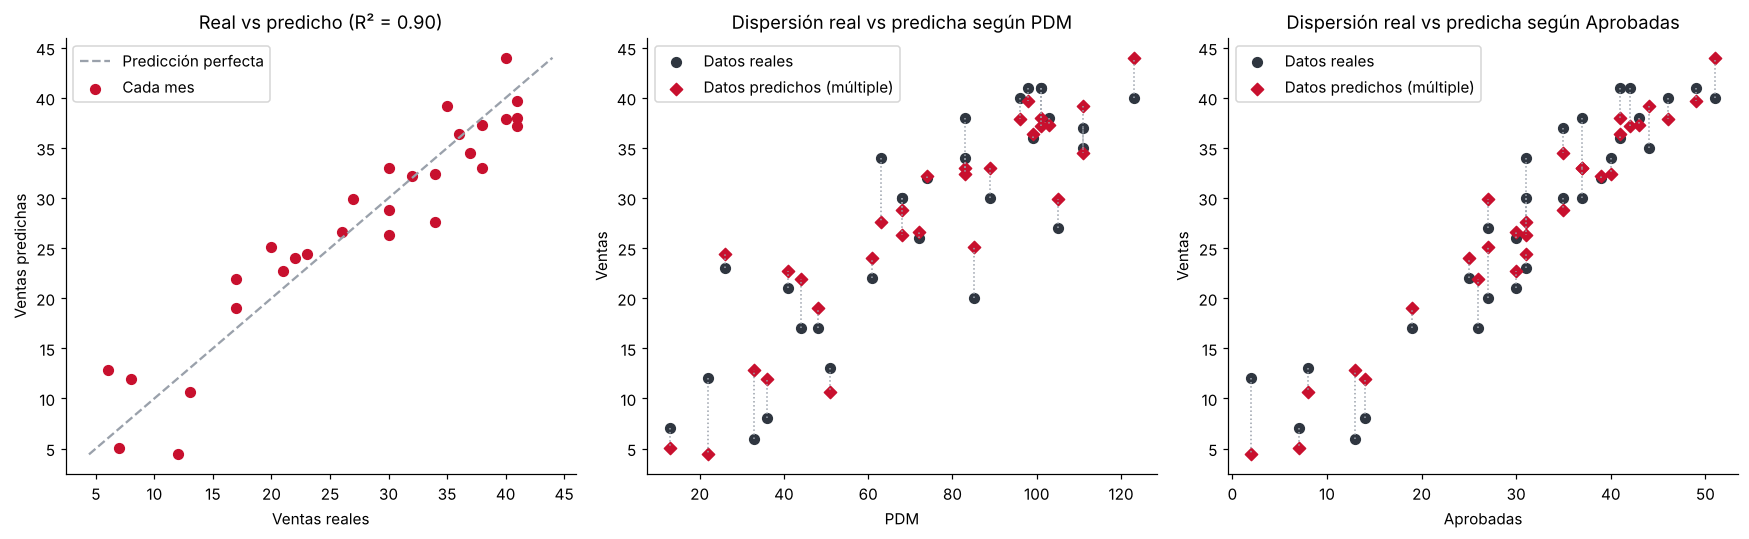

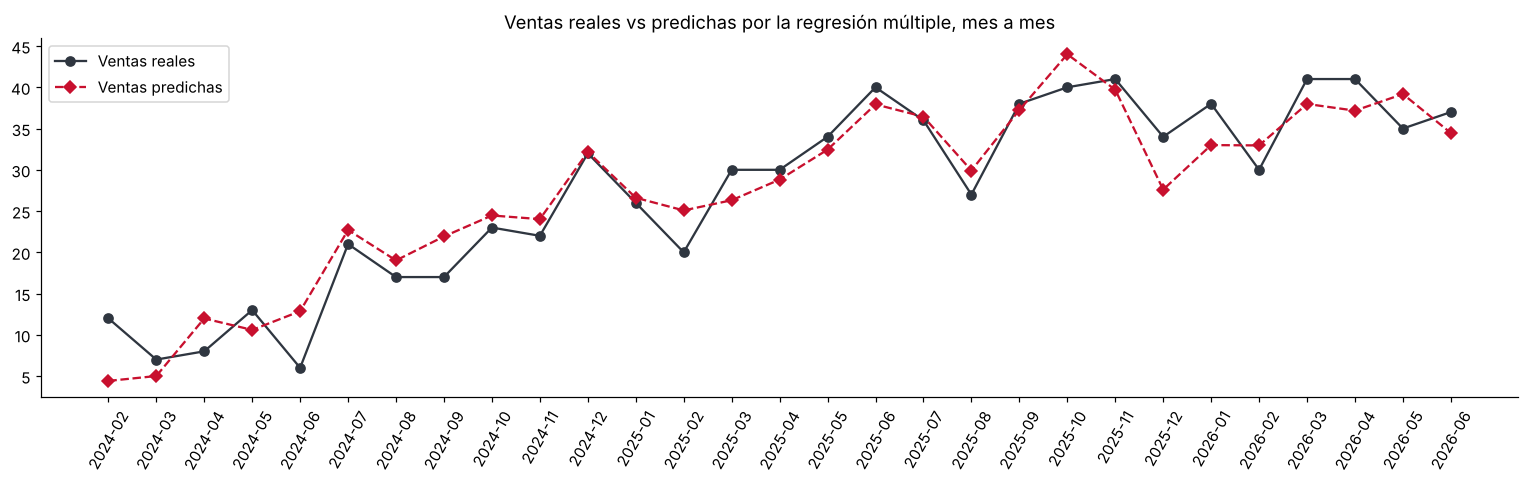

In [6]:
#GRÁFICAS de la regresión múltiple: real vs predicho y dispersión predicha superpuesta contra cada X
d = RLM["d"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#1) Real vs predicho: si el modelo fuera perfecto, todo caería en la línea punteada
lim = [min(d[Y].min(), RLM["pred"].min()), max(d[Y].max(), RLM["pred"].max())]
axes[0].plot(lim, lim, color=GRIS, linestyle="--", label="Predicción perfecta")
axes[0].scatter(d[Y], RLM["pred"], color=ROJO, s=40, label="Cada mes")
axes[0].set_xlabel("Ventas reales")
axes[0].set_ylabel("Ventas predichas")
axes[0].set_title(f"Real vs predicho (R² = {RLM['r2']:.2f})")
axes[0].legend()

#2) y 3) Dispersión real y predicha contra dos de las X del modelo
for ax, x in zip(axes[1:], ["PDM", "Aprobadas"]):
    ax.vlines(d[x], d[Y], RLM["pred"], colors=GRIS, linestyles="dotted", linewidth=1)
    ax.scatter(d[x], d[Y], color=CARBON, s=40, label="Datos reales")
    ax.scatter(d[x], RLM["pred"], color=ROJO, marker="D", s=32, label="Datos predichos (múltiple)")
    ax.set_xlabel(x)
    ax.set_ylabel(Y)
    ax.set_title(f"Dispersión real vs predicha según {x}")
    ax.legend()
plt.tight_layout()
plt.show()

#4) Línea de tiempo: ventas reales vs predichas por mes
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(d["Periodo"], d[Y], color=CARBON, marker="o", label="Ventas reales")
ax.plot(d["Periodo"], RLM["pred"], color=ROJO, marker="D", linestyle="--", label="Ventas predichas")
ax.set_title("Ventas reales vs predichas por la regresión múltiple, mes a mes")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
#Comparación final: simple vs múltiple
print(f"Mejor regresión simple: {Ranking_RLS['X'].iloc[0]} -> R² = {Ranking_RLS['R²'].iloc[0]:.3f}")
print(f"Regresión simple con Citas efectivas -> R² = {RLS['r2']:.3f}")
print(f"Regresión múltiple ({', '.join(XS)}) -> R² = {RLM['r2']:.3f}, R² ajustado = {RLM['r2a']:.3f}")

Mejor regresión simple: Aprobadas -> R² = 0.861
Regresión simple con Citas efectivas -> R² = 0.616
Regresión múltiple (Leads_Total, Citas_Efectivas, PDM, Aprobadas) -> R² = 0.896, R² ajustado = 0.879


### Lectura de resultados
- **Correlaciones:** las variables del final del embudo (solicitudes aprobadas y generadas, pruebas de manejo, citas efectivas) son las que más se mueven con las ventas; el volumen total de leads tiene una relación solo moderada.
- **Regresión simple:** Citas efectivas sola explica ~62% de las ventas; la mejor X sola es Solicitudes aprobadas (~86%). Aun así queda error mes a mes (las líneas punteadas).
- **Regresión múltiple:** con los 4 pasos del embudo el R² sube a ~0.90 (R² ajustado ~0.88), mejor que cualquier X sola. Las significativas (p < 0.05) son **Pruebas de manejo** y **Solicitudes aprobadas**; todos los VIF son menores a 5, así que no hay multicolinealidad grave.
- **Para el negocio:** lo que más se asocia con vender no es cuántos leads entran, sino cuántos clientes llegan a prueba de manejo y a crédito aprobado.
- **Cuidado:** son ~29 meses; los modelos describen asociación, no prueban causa. Se excluyeron columnas calculadas con las mismas ventas (Conversion, Cumplimiento, CAC/CAP) para no inflar el R².

---
# Dashboard (Etapa I + Etapa II)

Esta celda **no muestra el dashboard**: solo crea (o actualiza) el archivo `app.py` en la carpeta. En la barra lateral eliges la **Etapa** y luego la **Vista**. Si cambias algo del diseño, cámbialo aquí y vuelve a correrla.

In [ ]:
%%writefile app.py
#Creamos el archivo de la APP (Dashboard GAC Motor - Etapa I: Extracción de Características)
#####################################################
#Importamos librerias
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import os
import re
import io
import math
import numpy as np
import base64
from PIL import Image
######################################################
#Configuración de la página (pantalla ancha)
st.set_page_config(page_title="GAC Motor | Dashboard", layout="wide")

#PALETA (teoría del color): el rojo GAC es el ACENTO y solo marca lo que pide atención;
#los neutros (carbón y grises) son el contexto. Así el ojo va directo a lo importante.
ROJO = "#C8102E"        #Acento: lo más importante / alerta
ROJO_OSCURO = "#8E0B20" #Extremo de la escala de intensidad
CARBON = "#2F3640"      #Serie principal neutra (texto blanco encima se lee bien)
GRIS = "#9AA1AB"        #Contexto: lo que no necesita atención
GRIS_CLARO = "#D5D9DE"  #Contexto muy suave (siempre con etiqueta oscura)
VERDE = "#2E7D4F"       #Estado: cumple / bien (siempre con texto, nunca color solo)
TINTA = "#1F2328"       #Texto principal
TINTA_2 = "#5B6370"     #Texto secundario
FONDO_APP = "#F4F5F7"   #Fondo de la página
SUPERFICIE = "#FFFFFF"  #Tarjetas y gráficas
BORDE = "#E3E6EA"       #Bordes suaves

#Escala de intensidad (un solo tono, de claro a oscuro) para treemap y mapa de calor
ESCALA_ROJA = ["#FCE8EB", "#F4B3BD", "#E2647A", ROJO, ROJO_OSCURO]
#Colores con significado propio para los niveles de asesor
METALES = {"Oro": "#B8901F", "Plata": GRIS, "Bronce": "#A0582C"}

LOGO = os.path.join(os.path.dirname(os.path.abspath(__file__)), "logo_gac.png")
FONDO = os.path.join(os.path.dirname(os.path.abspath(__file__)), "auto fondo.jpeg")
DISCO = os.path.join(os.path.dirname(os.path.abspath(__file__)), "disco_freno.png")
CARBONO = os.path.join(os.path.dirname(os.path.abspath(__file__)), "fibra_carbono.png")
BRILLO = os.path.join(os.path.dirname(os.path.abspath(__file__)), "brillo_dona.png")
FUENTE = "Inter, 'Segoe UI', system-ui, -apple-system, sans-serif"

pio.templates["gac"] = go.layout.Template(layout=dict(
    font=dict(family=FUENTE, color=TINTA, size=13),
    paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
    colorway=[ROJO, CARBON, GRIS],
    xaxis=dict(gridcolor="#EDEFF2", linecolor=BORDE, zeroline=False,
               tickfont=dict(color=TINTA_2), title_font=dict(color=TINTA_2)),
    yaxis=dict(gridcolor="#EDEFF2", linecolor=BORDE, zeroline=False,
               tickfont=dict(color=TINTA_2), title_font=dict(color=TINTA_2)),
    legend=dict(font=dict(color=TINTA_2)),
    barcornerradius=4,
    hoverlabel=dict(bgcolor=SUPERFICIE, font=dict(color=TINTA, family=FUENTE), bordercolor=BORDE)))
pio.templates.default = "plotly_white+gac"

MESES = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

#Etapas del embudo en orden (de la primera a la última)
#Leads generados/efectivos NO se usan: vienen rellenados con la media (83.06 se repite)
ETAPAS = ["Cita programada", "Cita efectiva", "Prueba de manejo",
          "Solicitud de crédito generada", "Solicitud de crédito aprobada",
          "Ventas", "Formalizado"]

#Lista de las 15 variables: nombre en el dashboard -> (base, columna, tipo, medida)
#Medida = columna que se SUMA por categoría. Si es None, se cuentan registros.
VARIABLES = {
    "Canal (Funnel)":            ("Funnel", "Canal", "Categórica", "Real"),
    "Indicador del embudo":      ("Funnel", "Indicador", "Categórica", "Real"),
    "Campaña digital":           ("MKT_Digital", "Campaña", "Categórica", "Leads"),
    "Canal principal":           ("Principales_Canales", "Canal", "Categórica", "Ventas"),
    "Asesor de piso":            ("Analisis_de_Piso", "Asesor", "Categórica", "Ventas"),
    "Vendedor":                  ("Ventas_por_Asesor", "Vendedor", "Categórica", "Ventas"),
    "Ventas por asesor de piso": ("Analisis_de_Piso", "Ventas", "Numérica discreta", None),
    "Ventas por vendedor":       ("Ventas_por_Asesor", "Ventas", "Numérica discreta", None),
    "Bono de marketing":         ("Marketing", "Bono_Marketing", "Numérica discreta", None),
    "Bajas de personal":         ("TOPS_TDH", "Bajas", "Numérica discreta", None),
    "Vacantes":                  ("TOPS_TDH", "Vacantes", "Numérica discreta", None),
    "APVS Oro":                  ("TOPS_TDH", "APVS_Oro", "Numérica discreta", None),
    "APVS Plata":                ("TOPS_TDH", "APVS_Plata", "Numérica discreta", None),
    "APVS Bronce":               ("TOPS_TDH", "APVS_Bronce", "Numérica discreta", None),
    "Clima laboral":             ("TOPS_TDH", "Clima_Laboral", "Numérica discreta", None),
}

#Busca el CSV en la carpeta de app.py aunque tenga " 1", "(1)" o "_1" al final del nombre
CARPETA = os.path.dirname(os.path.abspath(__file__))
def leer(nombre):
    base = nombre[:-4]
    for variante in [nombre, f"{base} 1.csv", f"{base} (1).csv", f"{base}_1.csv", f"{base}(1).csv"]:
        ruta = os.path.join(CARPETA, variante)
        if os.path.exists(ruta):
            return pd.read_csv(ruta)
    st.error(f"No encuentro **{nombre}**. Ponlo en la misma carpeta que app.py: {CARPETA}")
    st.stop()

######################################################
#Definimos la instancia
@st.cache_resource
######################################################
#Creamos la función de carga de datos
def load_data():
    #Lectura de los archivos csv (una por una). Deben estar en la misma carpeta que app.py
    #No rellenamos nulos con bfill/ffill: un dato faltante no es igual al del mes vecino
    bases = {}
    bases["Analisis_de_Piso"] = leer("Analisis_de_Piso_Limpio.csv")
    bases["Funnel"] = leer("Funnel_Limpio.csv")
    bases["Leads_Reales"] = leer("Leads_Reales_Limpio.csv")
    bases["Marketing"] = leer("Marketing_Limpio.csv")
    bases["MKT_Digital"] = leer("MKT_Digital_Limpio.csv")
    bases["Principales_Canales"] = leer("Principales_Canales_Limpio.csv")
    bases["SDC"] = leer("SDC_Limpio.csv")
    bases["TOPS_TDH"] = leer("TOPS_TDH_Limpio.csv")
    bases["Ventas"] = leer("Ventas_Limpio.csv")
    bases["Ventas_por_Asesor"] = leer("Ventas_por_Asesor_Limpio.csv")
    #Bases nuevas de la Etapa II (una fila por mes)
    bases["Funnel_Ventas_Mensual"] = leer("Funnel_Ventas_Mensual.csv")
    bases["MKT_Digital_Mensual"] = leer("MKT_Digital_Mensual.csv")
    bases["Ventas_por_Asesor_Mensual"] = leer("Ventas_por_Asesor_Mensual.csv")

    #Unificamos nombres repetidos del mismo canal en Funnel
    bases["Funnel"]["Canal"] = bases["Funnel"]["Canal"].replace({
        "Plaza Ange": "Plaza Angelopólis",
        "Gran Patio": "Gran Patio Tlaxcala",
        "Prospeccion": "Estrategia de Prospeccion",
        "Plaza Pachuca (2)": "Plaza Pachuca",
        "Otros / Cartera / Casa": "Otros",
        "Otros / Custom": "Otros",
    })
    return bases

###############################################################################
#Cargo los datos obtenidos de la función "load_data"
bases = load_data()

###############################################################################
#FUNCIONES DE APOYO
#Escribe las categorías sin decimales de sobra: 2.0 -> "2"
def como_texto(valor):
    if isinstance(valor, float) and valor.is_integer():
        return str(int(valor))
    return str(valor)

#Prepara los datos de Funnel para que no se cuente doble
def preparar(df, variable):
    if variable == "Canal (Funnel)":
        #"GAC Angelopolis" es el TOTAL de la agencia (suma de los demás canales): lo quitamos
        #y medimos cada canal por sus ventas reales
        return df[(df["Indicador"] == "Ventas") & (df["Canal"] != "GAC Angelopolis")]
    if variable == "Indicador del embudo":
        #Usamos solo la fila del total para ver el embudo completo de la agencia
        return df[(df["Canal"] == "GAC Angelopolis") & (df["Indicador"].isin(ETAPAS))]
    return df

#Arma las frecuencias (o sumas) de cada categoría con su porcentaje
def frecuencias(df, columna, medida, tipo, variable=""):
    if medida:
        Datos = df.groupby(columna)[medida].sum().reset_index()
        if variable == "Canal (Funnel)":
            nombre = "Ventas"
        elif variable == "Indicador del embudo":
            nombre = "Clientes"
        else:
            nombre = medida
    else:
        Datos = df[columna].value_counts().reset_index()
        nombre = "Registros"
    Datos.columns = ["Categoría", nombre]
    #Las numéricas se ordenan 0, 1, 2...; las de texto de mayor a menor
    if tipo == "Numérica discreta":
        Datos = Datos.sort_values("Categoría")
    else:
        Datos = Datos.sort_values(nombre, ascending=False)
    Datos["Categoría"] = Datos["Categoría"].apply(como_texto)
    Datos[nombre] = Datos[nombre].round(0).astype(int)
    Datos["Porcentaje"] = (Datos[nombre] / max(Datos[nombre].sum(), 1) * 100).round(1)
    return Datos.reset_index(drop=True), nombre

#Datos del embudo (etapas en orden, real vs objetivo)
def datos_embudo(df):
    Embudo = (df.groupby("Indicador")[["Real", "Objetivo"]].sum()
              .reindex(ETAPAS).fillna(0).reset_index())
    Embudo["Real"] = Embudo["Real"].round(0).astype(int)
    Embudo["Cumplimiento"] = (Embudo["Real"] / Embudo["Objetivo"].replace(0, 1) * 100).round(0)
    Embudo["Pasa"] = (Embudo["Real"] / Embudo["Real"].shift(1) * 100).round(0)
    return Embudo

#Colores por barra: la(s) categoría(s) a destacar en rojo y el resto en gris (contexto)
def resaltar(categorias, destacar, base=GRIS):
    return [ROJO if c in destacar else base for c in categorias]

@st.cache_data
def imagen_b64(ruta, ancho=None):
    if not os.path.exists(ruta):
        return None
    imagen = Image.open(ruta)
    if ancho:
        imagen.thumbnail((ancho, ancho))
    buffer = io.BytesIO()
    formato = "JPEG" if imagen.mode == "RGB" else "PNG"
    imagen.save(buffer, format=formato, quality=88)
    return f"data:image/{formato.lower()};base64," + base64.b64encode(buffer.getvalue()).decode()

#Estilos generales (UX): se conservan los elementos de marca (auto de fondo, fibra de carbono,
#disco de freno, acabados metálicos) pero en segundo plano, para que los datos sean lo primero
def aplicar_estilos():
    fondo, carbono = imagen_b64(FONDO, 1600), imagen_b64(CARBONO)
    icono = imagen_b64(DISCO, 64)
    capa_fondo = f", url('{fondo}')" if fondo else ""
    capa_carbono = f", url('{carbono}')" if carbono else ""
    vineta = f"background: url('{icono}') no-repeat 0 0.62em / 1.05em;" if icono else ""
    st.markdown(f"""<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');
    html, body, .stApp, p, li, label, input, h1, h2, h3 {{ font-family: {FUENTE}; }}

    /* Fondo: el auto GAC se queda, aclarado con el gris de la página para no competir con las tarjetas */
    [data-testid="stAppViewContainer"] {{
        background: linear-gradient(rgba(244,245,247,0.55), rgba(244,245,247,0.55)){capa_fondo};
        background-size: cover; background-position: right bottom; background-attachment: fixed;
        background-color: {FONDO_APP};
    }}
    [data-testid="stHeader"] {{ background: transparent; }}
    .stMain .block-container {{ padding-top: 2.2rem; max-width: 1280px; }}

    /* Barra lateral de fibra de carbono, oscurecida para que el texto claro se lea bien */
    [data-testid="stSidebar"] {{
        background: linear-gradient(rgba(18,20,24,0.78), rgba(18,20,24,0.88)){capa_carbono};
        background-color: #16181D;
        border-right: 3px solid {ROJO};
        border-radius: 0 22px 22px 0;
        box-shadow: 4px 0 16px rgba(200,16,46,0.22);
    }}
    [data-testid="stSidebar"] p, [data-testid="stSidebar"] label,
    [data-testid="stSidebar"] [data-testid="stCaptionContainer"] {{ color: #C9CED6 !important; }}
    [data-testid="stSidebar"] [data-testid="stWidgetLabel"] p {{
        color: #FFFFFF !important; font-weight: 600; font-size: 0.82rem;
        text-transform: uppercase; letter-spacing: 0.06em;
    }}
    /* Controles con acabado metálico suave (plata clara, texto oscuro con buen contraste) */
    [data-testid="stSidebar"] :is([data-testid="stSelectbox"], [data-testid="stMultiSelect"]) > div:last-child > div {{
        background: linear-gradient(180deg, #FFFFFF 0%, #EEF0F3 55%, #E1E4E8 100%);
        border: 1px solid #8A9099; border-radius: 8px;
        box-shadow: inset 0 1px 0 #FFFFFF, 0 2px 6px rgba(0,0,0,0.35);
    }}
    [data-testid="stSidebar"] :is([data-testid="stSelectbox"], [data-testid="stMultiSelect"]) > div:last-child * {{ color: {TINTA} !important; }}
    [data-testid="stSidebar"] [data-testid="stMultiSelect"] [data-testid="stMultiSelectTagsContainer"] [role="group"] > span {{
        background: linear-gradient(180deg, #D8213D, {ROJO} 60%, #A80D27) !important;
        border: 1px solid {ROJO_OSCURO}; border-radius: 6px;
    }}
    [data-testid="stSidebar"] [data-testid="stMultiSelect"] [data-testid="stMultiSelectTagsContainer"] [role="group"] > span,
    [data-testid="stSidebar"] [data-testid="stMultiSelect"] [data-testid="stMultiSelectTagsContainer"] [role="group"] > span * {{ color: #FFFFFF !important; }}
    [data-testid="stSidebar"] hr {{ border-color: #2A2E35; }}

    /* Título con acabado metálico oscuro (alto contraste) y barra roja de acento */
    .stMain h1 {{
        font-weight: 800; letter-spacing: -0.02em;
        background: linear-gradient(180deg, #4A515C 0%, {TINTA} 50%, #3A4049 100%);
        -webkit-background-clip: text; background-clip: text; color: transparent;
        border-left: 6px solid {ROJO}; padding-left: 14px;
    }}
    .stMain h3 {{ color: {TINTA}; font-weight: 700; font-size: 1.2rem; }}
    .stMain [data-testid="stMarkdownContainer"] p {{ color: #3A4049; line-height: 1.6; }}
    .stMain [data-testid="stCaptionContainer"] p {{ color: {TINTA_2}; }}
    .stMain hr {{ border-color: rgba(31,35,40,0.12); }}

    /* Cada sección es una tarjeta blanca sobre el fondo del auto */
    .stMain [class*="st-key-seccion_"] {{
        background: rgba(255,255,255,0.94); backdrop-filter: blur(4px);
        border: 1px solid {BORDE} !important; border-radius: 14px;
        box-shadow: 0 1px 2px rgba(16,24,40,0.05), 0 6px 16px rgba(16,24,40,0.07);
    }}

    /* Puntos clave: el disco de freno como viñeta */
    .puntos-titulo {{ font-size: 0.75rem; font-weight: 700; color: {ROJO};
                      text-transform: uppercase; letter-spacing: 0.08em; margin: 0.4em 0 0.6em;
                      border-bottom: 2px solid {ROJO}; display: inline-block; padding-bottom: 2px; }}
    .stMain [data-testid="stMarkdownContainer"] ul {{ list-style: none; padding-left: 0; }}
    .stMain [data-testid="stMarkdownContainer"] li {{
        padding: 0.55em 0 0.55em 1.6em; margin: 0; {vineta}
        border-bottom: 1px solid #F0F2F4; color: #3A4049; line-height: 1.5;
    }}
    .stMain [data-testid="stMarkdownContainer"] li:last-child {{ border-bottom: none; }}
    .stMain [data-testid="stMarkdownContainer"] strong {{ color: {TINTA}; }}

    /* Tarjetas de indicadores (semitransparentes sobre el fondo) */
    [data-testid="stMetric"] {{
        background: rgba(255,255,255,0.88); backdrop-filter: blur(4px);
        border: 1px solid {BORDE}; border-top: 3px solid {ROJO};
        border-radius: 12px; padding: 14px 18px;
        box-shadow: 0 3px 10px rgba(16,24,40,0.10);
    }}
    [data-testid="stMetricLabel"] p {{ color: {TINTA_2} !important; font-weight: 600; }}
    [data-testid="stMetricValue"] {{ color: {TINTA}; font-weight: 700; }}
    </style>""", unsafe_allow_html=True)

#Donas: se conservan el brillo metálico, el disco de freno al centro y las etiquetas con flecha;
#las etiquetas ahora son blancas con borde del color de la rebanada y texto oscuro (se leen siempre)
def decorar_dona(fig):
    traza = fig.data[0]
    etiquetas, valores = list(traza.labels), list(traza.values)
    colores = list(traza.marker.colors or [ROJO, CARBON, GRIS])
    total = max(sum(valores), 1)
    fig.update_layout(height=400, margin=dict(t=50, b=50, l=20, r=20))
    radio = 150
    #Texto dentro de la rebanada: blanco sobre colores oscuros, oscuro sobre grises claros
    texto = ["white" if c in (ROJO, CARBON, ROJO_OSCURO) else TINTA for c in colores]
    fig.update_traces(sort=False, direction="clockwise", rotation=0, textinfo="label+percent",
                      textposition="inside", textfont=dict(size=14, color=texto),
                      marker=dict(colors=colores, line=dict(color=SUPERFICIE, width=2)))
    if os.path.exists(BRILLO):
        fig.add_layout_image(source=Image.open(BRILLO), xref="paper", yref="paper", x=0.5, y=0.5,
                             sizex=1, sizey=1, xanchor="center", yanchor="middle", layer="above",
                             opacity=0.6)
    if os.path.exists(DISCO):
        fig.add_layout_image(source=Image.open(DISCO), xref="paper", yref="paper", x=0.5, y=0.5,
                             sizex=0.5, sizey=0.5, xanchor="center", yanchor="middle", layer="above")
    acumulado = 0
    for i, (etiqueta, valor) in enumerate(zip(etiquetas, valores)):
        angulo = math.radians(90 - (acumulado + valor / 2) / total * 360)
        acumulado += valor
        color = colores[i % len(colores)]
        fig.add_annotation(x=0.5, y=0.5, xref="paper", yref="paper",
                           xshift=radio * 0.92 * math.cos(angulo), yshift=radio * 0.92 * math.sin(angulo),
                           ax=95 * math.cos(angulo), ay=-45 * math.sin(angulo),
                           text=f"{etiqueta} ({valor / total * 100:.1f}%)", showarrow=True,
                           arrowhead=0, arrowwidth=1.5, arrowcolor=TINTA_2,
                           bgcolor=SUPERFICIE, bordercolor=color, borderwidth=2, borderpad=6,
                           font=dict(color=TINTA, size=13))
    return fig

#Muestra una sección: pregunta arriba, gráfica a la izquierda y puntos clave a la derecha
#Con abajo=True la gráfica usa todo el ancho y los puntos clave van debajo (para gráficas grandes)
def seccion(pregunta, figura, puntos, alto=400, abajo=False, antes=None):
    with st.container(border=True, key="seccion_" + re.sub(r"\W", "_", pregunta)):
        st.subheader(pregunta)
        if antes:  #widgets que van entre el título y la gráfica
            antes()
        if abajo:
            Contenedor_Graf, Contenedor_Texto = st.container(), st.container()
        else:
            Contenedor_Graf, Contenedor_Texto = st.columns([2, 1], gap="large")
        with Contenedor_Graf:
            figura.update_layout(height=alto, margin=dict(t=20, b=20), title=None,
                                 paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
            #Números junto a las barras en texto oscuro, nunca del color de la barra
            figura.update_traces(outsidetextfont_color=TINTA, selector=dict(type="bar"))
            if figura.data and figura.data[0].type == "pie":
                decorar_dona(figura)
            st.plotly_chart(figura, width="stretch", key=pregunta, theme=None)
        with Contenedor_Texto:
            st.markdown('<div class="puntos-titulo">Puntos clave</div>', unsafe_allow_html=True)
            if abajo:  #los puntos clave en fila, uno por columna
                for col, p in zip(st.columns(len(puntos), gap="medium"), puntos):
                    col.markdown(f"- {p}")
            else:
                st.markdown("\n".join(f"- {p}" for p in puntos))

#Suma (o valor) de la variable en cada mes, ordenado en el tiempo
def serie_mensual(df, columna, medida):
    numero_mes = {m: f"{i:02d}" for i, m in enumerate(MESES, 1)}
    datos = df.copy()
    datos["Mes del año"] = datos["Año"].astype(str) + "-" + datos["Mes"].map(numero_mes)
    datos["Valor"] = datos[medida] if medida else datos[columna]
    return datos.groupby("Mes del año", as_index=False)["Valor"].sum().sort_values("Mes del año")

###############################################################################
#FUNCIONES DE LA ETAPA II (REGRESIÓN)
#Bases que se pueden modelar: nombre en el menú -> base
BASES_REG = {
    "Mensual combinada (todas las bases)": "Mensual_Combinada",
    "Marketing": "Marketing",
    "Leads reales": "Leads_Reales",
    "Solicitudes de crédito (SDC)": "SDC",
    "Principales canales": "Principales_Canales",
    "Funnel (embudo por canal)": "Funnel",
    "Análisis de piso (asesor por mes)": "Analisis_de_Piso",
    "TOPS / TDH (personal)": "TOPS_TDH",
    "Funnel: ventas vs objetivo mensual": "Funnel_Ventas_Mensual",
}
#X sugeridas al abrir la vista (el usuario las puede cambiar)
DEFAULT_X = {"Mensual_Combinada": "Citas_Efectivas", "Marketing": "Leads_Total",
             "Principales_Canales": "Citas_Efectivas", "Funnel": "Cita efectiva",
             "Analisis_de_Piso": "Leads", "Funnel_Ventas_Mensual": "Objetivo"}
DEFAULT_XS = {"Mensual_Combinada": ["Leads_Total", "Citas_Efectivas", "PDM", "Aprobadas"],
              "Marketing": ["Leads_Total", "Provision", "Bono_Marketing"],
              "Principales_Canales": ["Leads", "Citas_Efectivas", "PDM"],
              "Funnel": ["Cita efectiva", "Prueba de manejo", "Solicitud de crédito aprobada"],
              "SDC": ["Generadas", "Aprobadas", "Formalizadas"]}

#Nombre legible de una columna: Citas_Efectivas -> Citas Efectivas
def bonito(columna):
    return str(columna).replace("_", " ").replace("PDM", "Pruebas de manejo").replace("APVS", "asesores")

#Formato de números según su tamaño
def num(v):
    v = float(v)
    if abs(v) >= 1000:
        return f"{v:,.0f}"
    if abs(v) >= 1:
        return f"{v:,.2f}"
    return f"{v:.4f}"

#Fuerza de la relación según |r|
def fuerza(r):
    return "Fuerte" if abs(r) >= 0.7 else ("Moderada" if abs(r) >= 0.4 else "Débil")

#p-valor de dos colas con la t de Student (si no hay scipy, aproximación normal)
def p_valor(t, gl):
    try:
        from scipy import stats
        return 2 * stats.t.sf(np.abs(t), gl)
    except ImportError:
        return np.array([math.erfc(abs(x) / math.sqrt(2)) for x in np.atleast_1d(t)])

#Mínimos cuadrados ordinarios (OLS): Y = b0 + b1*X1 + ... + bk*Xk
def ols(df, y, xs):
    d = df.dropna(subset=[y] + xs)
    n, k = len(d), len(xs) + 1
    if n <= k:
        return None
    X = np.column_stack([np.ones(n)] + [d[x].to_numpy(float) for x in xs])
    Yv = d[y].to_numpy(float)
    beta = np.linalg.lstsq(X, Yv, rcond=None)[0]
    pred = X @ beta
    res = Yv - pred
    sse, sst = (res ** 2).sum(), ((Yv - Yv.mean()) ** 2).sum()
    gl = n - k
    r2 = 1 - sse / sst if sst > 0 else 0.0
    se = np.sqrt(np.diag(sse / gl * np.linalg.pinv(X.T @ X))) if gl > 0 else np.full(k, np.nan)
    t = np.divide(beta, se, out=np.zeros(k), where=se > 0)
    return {"d": d, "beta": beta, "se": se, "t": t, "p": p_valor(t, gl), "pred": pred, "res": res,
            "r2": r2, "r2a": 1 - (1 - r2) * (n - 1) / gl if gl > 0 else np.nan,
            "rmse": math.sqrt(sse / n), "n": n, "gl": gl}

#VIF: qué tanto se explica cada X con las demás X (mayor a 10 = multicolinealidad)
def vif(d, xs):
    salida = []
    for x in xs:
        m = ols(d, x, [o for o in xs if o != x])
        salida.append(np.inf if m is None or m["r2"] >= 0.9999 else 1 / (1 - m["r2"]))
    return salida

#Líneas punteadas entre cada dato real y su predicción (el error de cada punto)
def lineas_error(x, y_real, y_pred):
    sx, sy = [], []
    for xi, yr, yp in zip(x, y_real, y_pred):
        sx += [xi, xi, None]
        sy += [yr, yp, None]
    return go.Scatter(x=sx, y=sy, mode="lines", name="Error de predicción", hoverinfo="skip",
                      line=dict(color=GRIS, width=1, dash="dot"))

#Número con signo para la ecuación en LaTeX (+ 0.1424 / - 2.31)
def con_signo(v):
    return ("+ " if v >= 0 else "- ") + num(abs(v))

#Texto seguro para LaTeX: \text{Citas Efectivas}
def tx(nombre):
    return "\\text{" + bonito(nombre).replace("%", "\\%").replace("&", "\\&") + "}"

#APARTADO "ECUACIÓN ESTIMADA": la ecuación con los coeficientes y cómo se lee cada uno
def bloque_ecuacion(Y, xs, modelo, clave):
    beta, pv = modelo["beta"], modelo["p"]
    k = len(xs)
    with st.container(border=True, key="seccion_ecuacion_" + clave):
        st.subheader("Ecuación estimada")
        st.markdown('<div class="puntos-titulo">Ecuación con los datos</div>', unsafe_allow_html=True)
        #Un término por renglón cuando hay varias X, para que no se salga de la pantalla
        terminos = [f"{con_signo(b)} \\cdot {tx(x)}" for b, x in zip(beta[1:], xs)]
        if k <= 2:
            st.latex(r"\widehat{" + tx(Y) + "} = " + num(beta[0]) + " " + " ".join(terminos))
        else:
            st.latex(r"\begin{aligned} \widehat{" + tx(Y) + "} = \\; & " + num(beta[0]) + " \\\\ & "
                     + " \\\\ & ".join(terminos) + r" \end{aligned}")
        st.caption(f"Estimada por mínimos cuadrados ordinarios (MCO) · R² = {modelo['r2']:.2f} · n = {modelo['n']} registros")
        #Cómo se lee cada coeficiente (en palabras)
        st.markdown('<div class="puntos-titulo">Cómo se lee</div>', unsafe_allow_html=True)
        lectura = [f"**β₀ = {num(beta[0])}** (intercepto): valor estimado de {bonito(Y)} cuando "
                   + ("la X vale 0." if k == 1 else "todas las X valen 0; sirve para ajustar la recta, no siempre tiene sentido práctico.")]
        for i, (b, x, p) in enumerate(zip(beta[1:], xs, pv[1:]), 1):
            resto = "" if k == 1 else ", manteniendo las demás X igual"
            lectura.append(f"**β{str(i).translate(str.maketrans('0123456789', '₀₁₂₃₄₅₆₇₈₉'))} = {num(b)}**: por cada 1 más de "
                           f"**{bonito(x)}**, {bonito(Y)} {'sube' if b >= 0 else 'baja'} en promedio {num(abs(b))}{resto} · "
                           + ("**significativa** (p = " if p < 0.05 else "no significativa (p = ") + f"{p:.3f})")
        st.markdown("\n".join(f"- {t}" for t in lectura))

#Dibuja una figura de plotly con el estilo del dashboard (fondo transparente, texto oscuro)
def dibujar(figura, alto, clave):
    figura.update_layout(height=alto, margin=dict(t=10, b=20), title=None,
                         paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
    st.plotly_chart(figura, width="stretch", key=clave, theme=None)

#Puntos clave en una fila (uno por columna), debajo de la gráfica
def puntos_en_fila(puntos):
    st.markdown('<div class="puntos-titulo">Puntos clave</div>', unsafe_allow_html=True)
    for col, p in zip(st.columns(len(puntos), gap="medium"), puntos):
        col.markdown(f"- {p}")

#Arma la tabla numérica que usa el modelo según la base elegida
def tabla_regresion(base, canal=None):
    k = ["Año", "Mes"]
    if base == "Mensual_Combinada":
        #Una fila por mes uniendo las bases mensuales (solo meses que existen en Marketing)
        d = bases["Marketing"][k + ["Leads_Total", "Ventas", "Provision", "Reembolso_Total",
                                    "Bono_Marketing", "Aportacion_Agencia"]]
        piezas = [bases["Leads_Reales"][k + ["Efectivos", "No_Contesta", "Ilocalizable", "Abiertos"]],
                  bases["SDC"][k + ["Generadas", "Aprobadas", "Rechazadas", "Formalizadas"]],
                  bases["Principales_Canales"].groupby(k, as_index=False)[["Citas_Programadas",
                                                                           "Citas_Efectivas", "PDM"]].sum(),
                  bases["Funnel_Ventas_Mensual"][k + ["Objetivo"]].rename(columns={"Objetivo": "Objetivo_Ventas"}),
                  bases["Ventas_por_Asesor_Mensual"],
                  bases["MKT_Digital_Mensual"],
                  bases["TOPS_TDH"][k + ["Plantilla", "Operando", "Bajas", "Vacantes", "Productividad_APVS"]]]
        for p in piezas:
            d = d.merge(p, on=k, how="left")
    elif base == "Principales_Canales":
        d = bases[base].drop(columns=["Fecha", "Conversion", "Aporte"], errors="ignore")
        if canal and canal != "Todos (suma)":
            d = d[d["Canal"] == canal].drop(columns="Canal")
        else:
            d = d.groupby(k, as_index=False).sum(numeric_only=True)
    elif base == "Funnel":
        #Cada etapa del embudo pasa a ser una columna (valor real del canal en el mes)
        f = bases["Funnel"][bases["Funnel"]["Canal"] == canal]
        d = f.pivot_table(index=k, columns="Indicador", values="Real", aggfunc="sum").reset_index()
        d = d[k + [e for e in ETAPAS if e in d.columns]]
    elif base == "Analisis_de_Piso":
        d = bases[base][k + ["Asesor", "Leads", "Ventas"]]
    else:
        #Quitamos columnas que se calculan CON las ventas (p. ej. Conversion = Ventas / Leads):
        #usarlas como X sería "hacer trampa" porque ya traen la respuesta adentro
        d = bases[base].drop(columns=["Fecha", "Conversion", "Cumplimiento_Ventas",
                                      "CAP_General", "CAP_GAC", "CAC_General", "CAC_GAC"], errors="ignore")
    d = d.copy()
    numero_mes = {m: f"{i:02d}" for i, m in enumerate(MESES, 1)}
    d["Periodo"] = d["Año"].astype(str) + "-" + d["Mes"].map(numero_mes)
    if "Asesor" in d.columns:
        d["Periodo"] = d["Periodo"] + " · " + d["Asesor"]
    return d.sort_values("Periodo").reset_index(drop=True)

###############################################################################
#CATÁLOGO DE GRÁFICAS DEL ANÁLISIS UNIVARIADO
#Cada función regresa: (figura, pregunta, puntos clave)

#BARRAS HORIZONTALES: las 10 categorías más grandes
def g_barras(df, Datos, nombre, columna, medida, variable):
    d = Datos.head(10)
    fig = px.bar(d.iloc[::-1], x=nombre, y="Categoría", orientation="h", text="Porcentaje")
    fig.update_traces(texttemplate="%{text}%", textposition="outside", cliponaxis=False,
                      marker_color=resaltar(d["Categoría"].iloc[::-1], [Datos["Categoría"].iloc[0]]))
    fig.update_yaxes(type="category", title="")
    fig.update_xaxes(range=[0, d[nombre].max() * 1.2])
    top3 = Datos["Porcentaje"].head(3).sum()
    return fig, "¿Cuáles son las más grandes?", [
        f"**{Datos['Categoría'].iloc[0]}** es la primera con **{Datos['Porcentaje'].iloc[0]}%**.",
        f"Las 3 primeras juntan **{top3:.0f}%** del total.",
        f"Hay **{len(Datos)}** categorías en total."]

#LOLLIPOP (paleta): como barras pero más limpio para nombres de personas
def g_lollipop(df, Datos, nombre, columna, medida, variable):
    d = Datos.head(10).iloc[::-1]
    colores = resaltar(d["Categoría"], [Datos["Categoría"].iloc[0]])
    fig = px.scatter(d, x=nombre, y="Categoría", text=nombre)
    for (_, fila), color in zip(d.iterrows(), colores):
        fig.add_shape(type="line", x0=0, x1=fila[nombre], y0=fila["Categoría"], y1=fila["Categoría"],
                      line=dict(color=color, width=3), layer="below")
    fig.update_traces(marker=dict(size=16, color=colores, line=dict(color=SUPERFICIE, width=2)),
                      textposition="middle right", textfont_color=TINTA)
    fig.update_yaxes(type="category", title="")
    fig.update_xaxes(range=[0, d[nombre].max() * 1.2])
    lider, segundo = Datos.iloc[0], Datos.iloc[1]
    quienes = "personas" if variable in ("Asesor de piso", "Vendedor") else "canales"
    puntos = [f"**{lider['Categoría']}** lidera con **{lider[nombre]}** ventas ({lider['Porcentaje']}%).",
              f"Le sigue **{segundo['Categoría']}** con **{segundo[nombre]}**."]
    if len(Datos) > 10 and Datos["Porcentaje"].head(10).sum() < 99.5:
        puntos.append(f"El top 10 junta **{Datos['Porcentaje'].head(10).sum():.0f}%** de las ventas "
                      f"de {len(Datos)} {quienes}.")
    else:
        ceros = (Datos[nombre] == 0).sum()
        if ceros:
            puntos.append(f"**{ceros}** {quienes} no tuvieron ninguna venta.")
    pregunta = "¿Quiénes venden más?" if quienes == "personas" else "¿Qué canales venden más?"
    return fig, pregunta, puntos

#TREEMAP: cada cuadro es una categoría; su tamaño es lo que aporta
def g_treemap(df, Datos, nombre, columna, medida, variable):
    d = Datos.head(15)
    fig = px.treemap(d, path=[px.Constant("Total"), "Categoría"], values=nombre,
                     color=nombre, color_continuous_scale=ESCALA_ROJA)
    fig.update_traces(texttemplate="%{label}<br>%{value}", root_color=FONDO_APP,
                      marker_line=dict(color=SUPERFICIE, width=2))
    fig.update_layout(coloraxis_showscale=False)
    return fig, "¿Cuánto aporta cada uno?", [
        f"El cuadro más grande es **{Datos['Categoría'].iloc[0]}**: **{Datos['Porcentaje'].iloc[0]}%** del total.",
        f"Los 3 cuadros más grandes juntan **{Datos['Porcentaje'].head(3).sum():.0f}%**.",
        "Mientras más grande y oscuro el cuadro, más aporta."]

#DONA: pocas categorías
def g_dona(df, Datos, nombre, columna, medida, variable):
    Datos = Datos.copy()
    if variable == "Bono de marketing":
        Datos["Categoría"] = Datos["Categoría"].replace({"0": "Sin bono", "50000": "Con bono de $50,000"})
    fig = px.pie(Datos, names="Categoría", values=nombre, hole=0.5,
                 color_discrete_sequence=[ROJO, CARBON, GRIS])
    fig.update_traces(textinfo="label+percent", textfont_size=14, sort=False)
    fig.update_layout(showlegend=False)
    p = Datos.sort_values(nombre, ascending=False)
    if VARIABLES[variable][2] == "Numérica discreta":
        #Variables numéricas: hablamos de "registros" (meses), no de "parte del total"
        donde = "de los meses" if VARIABLES[variable][0] in ("TOPS_TDH", "Marketing") else "de los registros"
        puntos = [f"**{p['Categoría'].iloc[0]}** aparece en **{p['Porcentaje'].iloc[0]:.0f}%** {donde}."]
        if len(p) > 1:
            puntos.append(f"**{p['Categoría'].iloc[1]}** aparece en **{p['Porcentaje'].iloc[1]:.0f}%**.")
        pregunta = "¿Qué tan seguido aparece cada valor?"
    else:
        puntos = [f"**{p['Categoría'].iloc[0]}** ocupa **{p['Porcentaje'].iloc[0]}%** del total."]
        if len(p) > 1:
            puntos.append(f"Le sigue **{p['Categoría'].iloc[1]}** con **{p['Porcentaje'].iloc[1]}%**.")
        pregunta = "¿Qué parte del total es cada una?"
    return fig, pregunta, puntos

#DONA TOP 5 VS EL RESTO: muchas categorías
def g_top5(df, Datos, nombre, columna, medida, variable):
    resto = f"Las otras {len(Datos) - 5}"
    d = pd.DataFrame({"Grupo": ["Las 5 más grandes", resto],
                      "Valor": [Datos[nombre].head(5).sum(), Datos[nombre].iloc[5:].sum()]})
    fig = px.pie(d, names="Grupo", values="Valor", hole=0.5, color="Grupo",
                 color_discrete_map={"Las 5 más grandes": ROJO, resto: GRIS})
    fig.update_traces(textinfo="label+percent", textfont_size=14)
    fig.update_layout(showlegend=False)
    pct5 = Datos["Porcentaje"].head(5).sum()
    return fig, "¿Se concentra en pocas?", [
        f"Solo **5 de {len(Datos)}** juntan **{pct5:.0f}%** del total.",
        "Está **muy concentrado** en pocas." if pct5 >= 50 else "Está **repartido** entre muchas."]

#BARRA AL 100%: "de cada 100..."
def g_barra100(df, Datos, nombre, columna, medida, variable):
    d = Datos.copy()
    d["Total"] = "Ventas"
    fig = px.bar(d, x="Porcentaje", y="Total", color="Categoría", orientation="h", text="Categoría",
                 color_discrete_sequence=[ROJO, CARBON, GRIS_CLARO])
    fig.update_traces(texttemplate="%{text}<br>%{x:.0f}%", textposition="inside",
                      insidetextanchor="middle", textfont_size=16,
                      marker_line=dict(color=SUPERFICIE, width=2))
    #Texto blanco sobre colores oscuros y oscuro sobre el gris claro (contraste legible)
    for traza in fig.data:
        traza.insidetextfont = dict(color=TINTA if traza.marker.color == GRIS_CLARO else "white")
    fig.update_layout(showlegend=False, barmode="stack")
    fig.update_yaxes(visible=False)
    fig.update_xaxes(title="% de las ventas", range=[0, 100])
    partes = ", ".join(f"**{r['Porcentaje']:.0f}** de {r['Categoría']}" for _, r in d.iterrows())
    return fig, "De cada 100 ventas, ¿de dónde vienen?", [
        f"De cada 100 ventas: {partes}.",
        f"**{d['Categoría'].iloc[0]}** es el canal más fuerte, pero ninguno pasa de la mitad."]

#HISTOGRAMA: cuántas personas venden poco, regular o mucho
def g_histograma(df, Datos, nombre, columna, medida, variable):
    fig = px.histogram(Datos, x=nombre, nbins=10, color_discrete_sequence=[CARBON])
    fig.update_traces(marker_line_color="white", marker_line_width=2)
    fig.update_xaxes(title="Ventas totales por vendedor")
    fig.update_yaxes(title="Número de vendedores")
    mediana = Datos[nombre].median()
    altos = (Datos[nombre] >= 20).sum()
    return fig, "¿Cuántos vendedores venden poco y cuántos mucho?", [
        f"La mitad de los vendedores tiene **{mediana:.0f} ventas o menos** en total.",
        f"Solo **{altos} de {len(Datos)}** llegan a 20 ventas o más.",
        "Cada barra agrupa vendedores con ventas parecidas; la barra más alta es lo más común."]

#BARRAS VERTICALES: valores numéricos en orden 0, 1, 2...
def g_barras_v(df, Datos, nombre, columna, medida, variable):
    moda = Datos.sort_values(nombre, ascending=False)["Categoría"].iloc[0]
    fig = px.bar(Datos, x="Categoría", y=nombre, text="Porcentaje")
    fig.update_traces(texttemplate="%{text}%", textposition="outside", cliponaxis=False,
                      marker_color=resaltar(Datos["Categoría"], [moda]))
    fig.update_xaxes(type="category", title=variable)
    fig.update_yaxes(range=[0, Datos[nombre].max() * 1.2])
    p = Datos.sort_values(nombre, ascending=False).iloc[0]
    return fig, "¿Qué valor se repite más?", [
        f"El valor más común es **{p['Categoría']}** (**{p['Porcentaje']}%** de los registros).",
        f"Los valores van de **{Datos['Categoría'].iloc[0]}** a **{Datos['Categoría'].iloc[-1]}**."]

#DONA VENDIÓ / NO VENDIÓ
def g_vendio(df, Datos, nombre, columna, medida, variable):
    d = df[columna].apply(lambda v: "Vendió" if v > 0 else "No vendió").value_counts().reset_index()
    d.columns = ["Resultado", "Registros"]
    fig = px.pie(d, names="Resultado", values="Registros", hole=0.5, color="Resultado",
                 color_discrete_map={"Vendió": CARBON, "No vendió": ROJO})
    fig.update_traces(textinfo="label+percent", textfont_size=15)
    fig.update_layout(showlegend=False)
    sin = (df[columna] <= 0).mean() * 100
    return fig, "¿En cuántos meses hubo venta?", [
        f"En **{sin:.0f}%** de los registros no hubo ninguna venta.",
        f"Solo **{100 - sin:.0f} de cada 100** registros tienen al menos una venta."]

#VELOCÍMETRO: % de meses con al menos una venta
def g_gauge_venta(df, Datos, nombre, columna, medida, variable):
    pct = (df[columna] > 0).mean() * 100
    fig = go.Figure(go.Indicator(mode="gauge+number", value=pct, number={"suffix": "%"},
                                 gauge={"axis": {"range": [0, 100]}, "bar": {"color": ROJO}, "bgcolor": "#EEF0F3",
                                        "borderwidth": 0}))
    fig.update_traces(number_font=dict(color=TINTA, size=56))
    return fig, "¿Qué tan seguido vende un vendedor?", [
        f"Un vendedor cierra al menos una venta en **{pct:.0f}%** de sus meses.",
        f"En **{100 - pct:.0f}%** de los meses no vende nada.",
        "La aguja llena significaría que todos venden todos los meses."]

#VELOCÍMETRO DEL CLIMA LABORAL (escala de 1 a 5)
def g_gauge_clima(df, Datos, nombre, columna, medida, variable):
    prom = df[columna].mean()
    fig = go.Figure(go.Indicator(mode="gauge+number", value=prom, number={"valueformat": ".2f"},
                                 gauge={"axis": {"range": [0, 5]}, "bar": {"color": CARBON},
                                        "borderwidth": 0,
                                        #Zonas de lectura: bajo (rojo suave), medio, bueno (verde suave)
                                        "steps": [{"range": [0, 3], "color": "#F8D7DC"},
                                                  {"range": [3, 4], "color": "#EEF0F3"},
                                                  {"range": [4, 5], "color": "#D5EBDD"}]}))
    fig.update_traces(number_font=dict(color=TINTA, size=56))
    return fig, "¿Cómo está el clima laboral?", [
        f"El promedio es **{prom:.2f} de 5**: el equipo califica bien su ambiente de trabajo.",
        f"La calificación más baja fue **{df[columna].min()}** y la más alta **{df[columna].max()}**."]

#BOXPLOT: rango de un mes normal
def g_box(df, Datos, nombre, columna, medida, variable):
    fig = px.box(df, x=columna, points="all", hover_data=["Año", "Mes"], color_discrete_sequence=[CARBON])
    fig.update_xaxes(title=variable)
    q1, med, q3 = df[columna].quantile([0.25, 0.5, 0.75])
    peor = df.loc[df[columna].idxmax()]
    return fig, "¿Cuántos hay en un mes normal?", [
        f"En un mes normal hay **entre {como_texto(float(q1))} y {como_texto(float(q3))}** (la caja).",
        f"El valor de en medio es **{como_texto(float(med))}**.",
        f"El mes más alto fue **{peor['Mes']} {peor['Año']}** con **{como_texto(float(peor[columna]))}**."]

#VIOLÍN: forma de la distribución
def g_violin(df, Datos, nombre, columna, medida, variable):
    fig = px.violin(df, x=columna, box=True, points="all", hover_data=["Año", "Mes"],
                    color_discrete_sequence=[CARBON])
    fig.update_xaxes(title=variable)
    med = df[columna].median()
    return fig, "¿Dónde se concentran los meses?", [
        f"La mayoría de los meses tiene alrededor de **{como_texto(float(med))}**.",
        f"Va de **{como_texto(float(df[columna].min()))}** a **{como_texto(float(df[columna].max()))}** por mes.",
        "La parte más ancha de la figura es donde caen más meses."]

#LÍNEA MES A MES
def g_linea(df, Datos, nombre, columna, medida, variable):
    s = serie_mensual(df, columna, medida)
    fig = px.line(s, x="Mes del año", y="Valor", markers=True, color_discrete_sequence=[CARBON],
                  labels={"Valor": variable})
    fig.update_xaxes(type="category", title="")
    alto, bajo = s.loc[s["Valor"].idxmax()], s.loc[s["Valor"].idxmin()]
    #El punto más alto se marca en rojo (es el primer punto clave)
    fig.update_traces(line_width=2, marker=dict(size=9, line=dict(color=SUPERFICIE, width=2),
                      color=resaltar(s["Mes del año"], [alto["Mes del año"]], base=CARBON)))
    return fig, "¿Cómo se movió mes a mes?", [
        f"El punto más alto fue **{alto['Mes del año']}** con **{como_texto(float(alto['Valor']))}**.",
        f"El más bajo fue **{bajo['Mes del año']}** con **{como_texto(float(bajo['Valor']))}**.",
        f"Empezó en **{como_texto(float(s['Valor'].iloc[0]))}** y terminó en "
        f"**{como_texto(float(s['Valor'].iloc[-1]))}**."]

#BARRAS POR MES: en qué meses hubo bono
def g_bono_mes(df, Datos, nombre, columna, medida, variable):
    s = serie_mensual(df, columna, None)
    s["Bono"] = s["Valor"].apply(lambda v: "Con bono" if v > 0 else "Sin bono")
    s["Altura"] = 1
    fig = px.bar(s, x="Mes del año", y="Altura", color="Bono",
                 color_discrete_map={"Con bono": ROJO, "Sin bono": GRIS_CLARO})
    fig.update_xaxes(type="category", title="")
    fig.update_yaxes(visible=False)
    fig.update_layout(legend_title="", legend=dict(orientation="h", y=-0.3, x=0), bargap=0.1)
    con = s[s["Bono"] == "Con bono"]
    puntos = [f"Hubo bono en **{len(con)} de {len(s)}** meses."]
    if len(con):
        puntos.append(f"El primer bono llegó en **{con['Mes del año'].iloc[0]}**; antes nunca hubo.")
    return fig, "¿En qué meses hubo bono?", puntos

#Qué dos gráficas lleva cada variable
GRAFICAS = {
    "Canal (Funnel)":            [g_treemap, g_lollipop],
    "Campaña digital":           [g_barras, g_top5],
    "Canal principal":           [g_barra100, g_dona],
    "Asesor de piso":            [g_lollipop, g_top5],
    "Vendedor":                  [g_treemap, g_histograma],
    "Ventas por asesor de piso": [g_barras_v, g_vendio],
    "Ventas por vendedor":       [g_barras_v, g_gauge_venta],
    "Bono de marketing":         [g_dona, g_bono_mes],
    "Bajas de personal":         [g_barras_v, g_linea],
    "Vacantes":                  [g_box, g_linea],
    "APVS Oro":                  [g_dona, g_linea],
    "APVS Plata":                [g_barras_v, g_box],
    "APVS Bronce":               [g_violin, g_linea],
    "Clima laboral":             [g_gauge_clima, g_dona],
}

###############################################################################
#CREACIÓN DEL DASHBOARD
#Generamos los encabezados para la barra lateral (sidebar)
aplicar_estilos()
#Si el equipo guarda el logo como logo_gac.png junto a app.py, aparece aquí
if os.path.exists(LOGO):
    st.sidebar.image(LOGO, width=200)
else:
    st.sidebar.title("GAC MOTOR")

#Widget 0: Radio para elegir la etapa del proyecto
Etapa = st.sidebar.radio("Etapa", ["Etapa I · Extracción de características",
                                   "Etapa II · Modelado predictivo"])
#Widget 1: Selectbox
#Menu desplegable de las vistas de cada etapa
if Etapa.startswith("Etapa I ·"):
    View = st.sidebar.selectbox(label="Vista", options=["Hallazgos principales",
                                                        "Análisis univariado",
                                                        "Comparación por periodo"])
else:
    View = st.sidebar.selectbox(label="Vista", options=["Resumen de modelos (todas las bases)",
                                                        "a) Análisis de correlaciones",
                                                        "Regresión lineal simple",
                                                        "Regresión lineal múltiple"])

###############################################################################
# CONTENIDO DE LA VISTA 1: HALLAZGOS PRINCIPALES
if View == "Hallazgos principales":
    st.title("Hallazgos principales")
    st.write("Las cinco respuestas más importantes que salen de las 15 variables. "
             "Para ver cualquier variable a detalle, elige **Análisis univariado** en el menú.")
    st.divider()

    #HALLAZGO 1: ventas por canal principal
    Canales, _ = frecuencias(bases["Principales_Canales"], "Canal", "Ventas", "Categórica")
    figure1 = px.pie(Canales, names="Categoría", values="Ventas", hole=0.5,
                     color_discrete_sequence=[ROJO, CARBON, GRIS])
    figure1.update_traces(textinfo="label+percent", textfont_size=15, sort=False)
    figure1.update_layout(showlegend=False)
    seccion("1. ¿Por dónde llegan las ventas?", figure1, [
        f"**{Canales['Categoría'].iloc[0]}** es el canal que más vende: "
        f"**{Canales['Porcentaje'].iloc[0]:.0f}%** de {Canales['Ventas'].sum():,} ventas.",
        f"**{Canales['Categoría'].iloc[1]}** sigue con **{Canales['Porcentaje'].iloc[1]:.0f}%**.",
        "Ningún canal pasa de la mitad: las ventas están repartidas."])

    #HALLAZGO 2: embudo de venta
    Embudo = datos_embudo(preparar(bases["Funnel"], "Indicador del embudo"))
    citas = Embudo["Real"].iloc[0]
    ventas = Embudo.loc[Embudo["Indicador"] == "Ventas", "Real"].iloc[0]
    fuga = Embudo.iloc[1:].sort_values("Pasa").iloc[0]
    figure2 = px.funnel(Embudo, x="Real", y="Indicador")
    figure2.update_traces(textinfo="value", textfont_color="white",
                          marker_color=resaltar(Embudo["Indicador"], [fuga["Indicador"]], base=CARBON))
    figure2.update_yaxes(title="")
    seccion("2. ¿Cuántos clientes llegan hasta la venta?", figure2, [
        f"De **{citas:,}** citas se cierran **{ventas:,}** ventas.",
        f"**{ventas / citas * 100:.0f} de cada 100** citas terminan en venta.",
        f"La mayor pérdida es al llegar a **{fuga['Indicador']}**: solo pasa el **{fuga['Pasa']:.0f}%**."])

    #HALLAZGO 3: campañas que traen más leads
    Campanas, _ = frecuencias(bases["MKT_Digital"], "Campaña", "Leads", "Categórica")
    Top5 = Campanas.head(5)
    figure3 = px.bar(Top5.iloc[::-1], x="Leads", y="Categoría", orientation="h", text="Leads")
    figure3.update_traces(textposition="outside", cliponaxis=False,
                          marker_color=resaltar(Top5["Categoría"].iloc[::-1], [Top5["Categoría"].iloc[0]]))
    figure3.update_yaxes(title="")
    figure3.update_xaxes(range=[0, Top5["Leads"].max() * 1.2])
    seccion("3. ¿Qué campañas digitales traen más leads?", figure3, [
        f"Las 5 campañas juntan **{Top5['Porcentaje'].sum():.0f}%** de los leads.",
        f"**{Top5['Categoría'].iloc[0]}** trae sola el **{Top5['Porcentaje'].iloc[0]:.0f}%**.",
        "Las campañas de WhatsApp dominan el top."])

    #HALLAZGO 4: vendedores con y sin venta en el mes
    Vendedores = bases["Ventas_por_Asesor"]
    figure4, _, _ = g_vendio(Vendedores, None, None, "Ventas", None, "")
    sin_venta = (Vendedores["Ventas"] <= 0).mean() * 100
    seccion("4. ¿Los vendedores venden cada mes?", figure4, [
        f"En **{sin_venta:.0f}%** de los meses el vendedor no cerró ninguna venta.",
        "Las ventas dependen de pocos vendedores."])

    #HALLAZGO 5: nivel de los asesores (personal)
    Niveles = pd.DataFrame({
        "Nivel": ["Oro", "Plata", "Bronce"],
        "Asesores al mes": [bases["TOPS_TDH"]["APVS_Oro"].mean(),
                            bases["TOPS_TDH"]["APVS_Plata"].mean(),
                            bases["TOPS_TDH"]["APVS_Bronce"].mean()]}).round(1)
    figure5 = px.bar(Niveles, x="Nivel", y="Asesores al mes", text="Asesores al mes",
                     color="Nivel", color_discrete_map=METALES)
    figure5.update_traces(textposition="outside", cliponaxis=False)
    figure5.update_layout(showlegend=False)
    figure5.update_yaxes(range=[0, Niveles["Asesores al mes"].max() * 1.25])
    seccion("5. ¿Qué nivel tienen los asesores?", figure5, [
        f"En un mes promedio hay **{Niveles['Asesores al mes'].iloc[2]:.0f} Bronce** y solo "
        f"**{Niveles['Asesores al mes'].iloc[0]:.0f} Oro**.",
        "La mayoría del equipo está en el nivel más bajo."])

    st.caption("El conjunto incluye 6 variables categóricas y 9 numéricas discretas. "
               "Confirmen con el profesor si las 15 deben ser estrictamente categóricas.")

###############################################################################
# FILTROS DE LAS VISTAS 2 Y 3 (en la barra lateral)
elif View in ("Análisis univariado", "Comparación por periodo"):
    #Separamos visualmente la vista de los filtros
    st.sidebar.divider()
    #Widget 2: Selectbox de base de datos
    Base = st.sidebar.selectbox(label="Base de datos",
                                options=sorted({b for b, _, _, _ in VARIABLES.values()}))
    #Widget 3: Selectbox de variable (solo las de la base elegida)
    Variable_Cat = st.sidebar.selectbox(label="Variable",
                                        options=[v for v, d in VARIABLES.items() if d[0] == Base])
    _, columna, tipo, medida = VARIABLES[Variable_Cat]

    #Widget 4 y 5: años y meses (solo los que existen en la base elegida)
    df = bases[Base]
    anios = sorted(df["Año"].unique())
    Anio_sel = st.sidebar.multiselect("Año", options=anios, default=anios)
    meses = [m for m in MESES if m in df.loc[df["Año"].isin(Anio_sel), "Mes"].unique()]
    Mes_sel = st.sidebar.multiselect("Mes", options=meses, default=meses)
    df = df[df["Año"].isin(Anio_sel) & df["Mes"].isin(Mes_sel)]
    df = preparar(df, Variable_Cat)

    if df.empty:
        st.warning("No hay datos con esos filtros. Elige al menos un año y un mes.")
        st.stop()

    #Frecuencias de la variable seleccionada (se usan en las gráficas)
    Datos, nombre = frecuencias(df, columna, medida, tipo, Variable_Cat)
    Principal = Datos.sort_values(nombre, ascending=False).iloc[0]

    ###########################################################################
    # CONTENIDO DE LA VISTA 2: ANÁLISIS UNIVARIADO
    if View == "Análisis univariado":
        st.title(Variable_Cat)

        #-------------------------------------------------------------------
        #CASO ESPECIAL: INDICADOR DEL EMBUDO
        if Variable_Cat == "Indicador del embudo":
            st.write("Cuántos clientes avanzan en cada paso del proceso de venta, "
                     "desde que agendan una cita hasta que se formaliza la compra.")
            st.divider()
            Embudo = datos_embudo(df)
            fuga = Embudo.iloc[1:].sort_values("Pasa").iloc[0]
            anterior = ETAPAS[ETAPAS.index(fuga["Indicador"]) - 1]
            citas = Embudo["Real"].iloc[0]
            ventas = Embudo.loc[Embudo["Indicador"] == "Ventas", "Real"].iloc[0]

            #GRAPH 1: EMBUDO (FUNNEL)
            figure1 = px.funnel(Embudo, x="Real", y="Indicador")
            figure1.update_traces(textinfo="value+percent previous", textfont_color="white",
                                  marker_color=resaltar(Embudo["Indicador"], [fuga["Indicador"]], base=CARBON))
            figure1.update_yaxes(title="")
            seccion("¿Cuántos clientes llegan a cada paso?", figure1, [
                f"De **{citas:,}** citas se cierran **{ventas:,}** ventas "
                f"(**{ventas / max(citas, 1) * 100:.0f} de cada 100**).",
                f"La mayor pérdida: de **{anterior}** a **{fuga['Indicador']}** solo pasa el "
                f"**{fuga['Pasa']:.0f}%**.",
                "El % de cada barra es cuántos avanzaron desde el paso anterior."])

            #GRAPH 2: CUMPLIMIENTO DEL OBJETIVO POR ETAPA
            Embudo["Estado"] = Embudo["Cumplimiento"].apply(
                lambda c: "Cumple la meta" if c >= 100 else "No cumple la meta")
            figure2 = px.bar(Embudo.iloc[::-1], x="Cumplimiento", y="Indicador", orientation="h",
                             text="Cumplimiento", color="Estado",
                             color_discrete_map={"Cumple la meta": VERDE, "No cumple la meta": ROJO})
            figure2.update_traces(texttemplate="%{text:.0f}%", textposition="outside", cliponaxis=False)
            figure2.add_vline(x=100, line_dash="dash", line_color=TINTA, line_width=1.5,  #Meta = 100%
                              annotation_text="Meta", annotation_position="top",
                              annotation_font_color=TINTA)
            figure2.update_yaxes(title="")
            figure2.update_xaxes(title="Cumplimiento (%)",
                                 range=[0, max(Embudo["Cumplimiento"].max(), 100) * 1.2])
            figure2.update_layout(legend_title="", legend=dict(orientation="h", y=-0.2, x=0))
            peor = Embudo.sort_values("Cumplimiento").iloc[0]
            cumplen = (Embudo["Cumplimiento"] >= 100).sum()
            seccion("¿Qué pasos alcanzan su meta?", figure2, [
                f"Solo **{cumplen} de {len(Embudo)}** pasos llegan a su meta (línea punteada).",
                f"El más lejos es **{peor['Indicador']}**, con **{peor['Cumplimiento']:.0f}%**.",
                "Los primeros pasos cumplen; el problema está al final del proceso."])

            st.caption("Nota: no se incluyen Leads generados ni Leads efectivos porque vienen rellenados "
                       "con la media (83.06 se repite en varios meses), ni Cerrador (solo aparece un mes).")

        #-------------------------------------------------------------------
        #RESTO DE LAS VARIABLES: cada una con sus dos gráficas del catálogo
        else:
            if Variable_Cat == "Canal (Funnel)":
                st.write("Ventas de cada canal. Se quitó GAC Angelopolis porque es el total de la agencia.")
            elif tipo == "Numérica discreta":
                st.write(f"Cómo se reparten los valores de **{Variable_Cat}** en la base {Base}.")
            else:
                st.write(f"Cuánto aporta cada categoría al total de **{nombre.lower()}** en la base {Base}.")

            #Fila de tarjetas (solo 3)
            Contenedor_A, Contenedor_B, Contenedor_C = st.columns(3)
            Contenedor_A.metric("Número de categorías", len(Datos))
            Contenedor_B.metric("Valor más común" if tipo == "Numérica discreta" else "La más grande",
                                Principal["Categoría"])
            Contenedor_C.metric("Su parte del total", f"{Principal['Porcentaje']}%")
            st.divider()

            #GRAPH 1 y GRAPH 2: las que le tocan a esta variable
            usadas = []
            for grafica in GRAFICAS[Variable_Cat]:
                #Si una gráfica necesita más categorías de las que dejan los filtros, usamos barras
                if grafica in (g_top5, g_lollipop) and len(Datos) <= 5:
                    grafica = g_barras
                if grafica in (g_box, g_violin, g_linea) and len(df) < 3:
                    grafica = g_barras_v
                if grafica in usadas:  #No repetir la misma gráfica dos veces
                    continue
                usadas.append(grafica)
                figura, pregunta, puntos = grafica(df, Datos, nombre, columna, medida, Variable_Cat)
                seccion(pregunta, figura, puntos)

            #Notas que solo aparecen cuando aplican
            if columna == "Ventas" and not medida:
                st.caption("Nota: los valores con decimales (0.18 y 0.53) vienen así en la base limpia; "
                           "son promedios usados para rellenar datos faltantes, no ventas reales.")
            if Base == "TOPS_TDH":
                st.caption("Nota: TOPS_TDH tiene un registro por mes (19 en total); tómalo como referencia, "
                           "no como tendencia firme.")

    ###########################################################################
    # CONTENIDO DE LA VISTA 3: COMPARACIÓN POR PERIODO
    elif View == "Comparación por periodo":
        st.title(f"{Variable_Cat}: cambio en el tiempo")
        st.write("Compara cómo cambia la variable de un periodo a otro.")

        #Widget 6: Radio para comparar por año o por mes
        Periodo = st.radio("Comparar por", ["Año", "Mes"], horizontal=True)
        st.divider()
        datos = df.copy()
        #Año-mes para no juntar, por ejemplo, febrero 2024 con febrero 2025
        numero_mes = {m: f"{i:02d}" for i, m in enumerate(MESES, 1)}
        datos["AñoMes"] = datos["Año"].astype(str) + "-" + datos["Mes"].map(numero_mes)
        datos["Categoría"] = datos[columna].apply(como_texto)
        datos["Valor"] = datos[medida] if medida else 1
        #Primero sumamos cada categoría por mes (un renglón por categoría y mes)
        datos = datos.groupby(["Año", "AñoMes", "Categoría"], as_index=False)["Valor"].sum()
        if Periodo == "Año":
            #Los años no tienen los mismos meses (2026 llega solo a medio año), así que
            #comparamos el PROMEDIO POR MES de cada año y no el total
            meses_por_anio = datos.groupby("Año")["AñoMes"].nunique()
            datos = datos.groupby(["Año", "Categoría"], as_index=False)["Valor"].sum()
            datos["Valor"] = (datos["Valor"] / datos["Año"].map(meses_por_anio)).round(1)
            datos["Periodo"] = datos["Año"].astype(str)
            etiqueta = f"{nombre} (promedio por mes)"
            st.caption("Por año se compara el promedio por mes, porque no todos los años tienen "
                       "los mismos meses: " + ", ".join(f"{a} tiene {n} meses"
                                                       for a, n in meses_por_anio.items()) + ".")
        else:
            datos["Periodo"] = datos["AñoMes"]
            etiqueta = nombre
        #Formato de los números: con un decimal si son promedios
        fmt = ",.1f" if Periodo == "Año" else ",.0f"

        #Categorías a mostrar: etapas en orden para el embudo; las 8 más grandes para lo demás
        if Variable_Cat == "Indicador del embudo":
            top8 = [e for e in ETAPAS if e in set(datos["Categoría"])]
        else:
            top8 = list(Datos.sort_values(nombre, ascending=False).head(8)["Categoría"])

        #GRAPH 3: BARRAS de una categoría en cada periodo
        #Widget 7: elegir una categoría para ver cómo cambia
        Categoria_sel = st.selectbox("Elige una categoría", options=top8)
        Serie = (datos[datos["Categoría"] == Categoria_sel]
                 .groupby("Periodo")["Valor"].sum().reset_index())
        figure3 = px.bar(Serie, x="Periodo", y="Valor", text="Valor", labels={"Valor": etiqueta})
        #El periodo más alto en rojo; el resto en carbón
        pico = Serie.loc[Serie["Valor"].idxmax(), "Periodo"]
        figure3.update_traces(texttemplate="%{text:" + fmt + "}", textposition="outside", cliponaxis=False,
                              marker_color=resaltar(Serie["Periodo"], [pico], base=CARBON))
        figure3.update_xaxes(type="category")
        figure3.update_yaxes(range=[0, max(Serie["Valor"].max(), 1) * 1.2])
        puntos = []
        if len(Serie) > 1 and Serie["Valor"].iloc[0] > 0:
            cambio = (Serie["Valor"].iloc[-1] / Serie["Valor"].iloc[0] - 1) * 100
            puntos.append(f"De {Serie['Periodo'].iloc[0]} a {Serie['Periodo'].iloc[-1]} "
                          f"{'subió' if cambio >= 0 else 'bajó'} **{abs(cambio):.0f}%**.")
        alto = Serie.loc[Serie["Valor"].idxmax()]
        puntos.append(f"El periodo más alto fue **{alto['Periodo']}** con **{alto['Valor']:{fmt}}**.")
        if len(Serie) > 2:
            bajo = Serie.loc[Serie["Valor"].idxmin()]
            puntos.append(f"El más bajo fue **{bajo['Periodo']}** con **{bajo['Valor']:{fmt}}**.")
        seccion(f"¿Cómo cambió {Categoria_sel}?", figure3, puntos)

        #GRAPH 4: HEATMAP (categorías principales x periodo)
        Heat = datos.pivot_table(index="Categoría", columns="Periodo", values="Valor",
                                 aggfunc="sum", fill_value=0)
        Heat = Heat.reindex(top8, fill_value=0)
        figure4 = px.imshow(Heat, text_auto=fmt.replace(",", ""), aspect="auto", color_continuous_scale=ESCALA_ROJA,
                            labels={"color": etiqueta, "x": "Periodo", "y": ""})
        figure4.update_xaxes(type="category")
        mejor = Heat.stack().idxmax()
        #Categoría que más creció entre el primer y el último periodo
        puntos = [f"El cuadro más oscuro es **{mejor[0]}** en **{mejor[1]}**."]
        if Heat.shape[1] > 1:
            crecimiento = (Heat.iloc[:, -1] - Heat.iloc[:, 0])
            puntos.append(f"La que más creció fue **{crecimiento.idxmax()}** y la que más bajó "
                          f"**{crecimiento.idxmin()}**.")
        puntos.append("Lee cada fila de izquierda a derecha: si se oscurece, va subiendo.")
        seccion("Mapa de calor: todas las categorías a la vez", figure4, puntos)

###############################################################################
# ETAPA II: MODELADO PREDICTIVO (resumen, correlaciones, regresión simple y múltiple)
elif View == "Resumen de modelos (todas las bases)":
    #Corre una regresión simple y una múltiple en CADA base para comparar de un vistazo
    st.title("Etapa II · Resumen de modelos")
    st.write("Para cada base se predice su variable principal con la **mejor regresión lineal simple** "
             "(la X con mayor R²) y con una **regresión lineal múltiple**. Para ver cada modelo a detalle, "
             "elige *Regresión lineal simple* o *Regresión lineal múltiple* en el menú.")
    st.divider()
    filas = []
    for nombre_b, clave in BASES_REG.items():
        canal_b = "GAC Angelopolis" if clave == "Funnel" else ("Todos (suma)" if clave == "Principales_Canales" else None)
        t = tabla_regresion(clave, canal_b)
        nums = [c for c in t.select_dtypes("number").columns if c != "Año" and t[c].nunique() > 1]
        y_b = next((p for p in ["Ventas", "Real", "Productividad_APVS"] if p in nums), nums[0])
        cand = [c for c in nums if c != y_b]
        cy = t[cand].corrwith(t[y_b]).dropna()
        cy = cy.reindex(cy.abs().sort_values(ascending=False).index)
        simples = {c: ols(t, y_b, [c]) for c in cand}
        simples = {c: m for c, m in simples.items() if m}
        x_mejor = max(simples, key=lambda c: simples[c]["r2"])
        xs_b = [x for x in DEFAULT_XS.get(clave, []) if x in cand] or list(cy.index[:3])
        mm = ols(t, y_b, xs_b) if len(xs_b) >= 2 else None
        filas.append({"Base": nombre_b, "Y (a predecir)": bonito(y_b),
                      "Mejor X (simple)": bonito(x_mejor), "R² simple": simples[x_mejor]["r2"],
                      "X del modelo múltiple": ", ".join(bonito(x) for x in xs_b) if mm else "— (solo hay 1 X)",
                      "R² múltiple": mm["r2"] if mm else np.nan,
                      "R² ajustado": mm["r2a"] if mm else np.nan,
                      "n": simples[x_mejor]["n"]})
    Resumen = pd.DataFrame(filas)

    #GRAPH E2-1: BARRAS R² simple vs múltiple por base
    Larga = Resumen.melt(id_vars="Base", value_vars=["R² simple", "R² múltiple"],
                         var_name="Modelo", value_name="R²").dropna()
    figE1 = px.bar(Larga, x="R²", y="Base", color="Modelo", barmode="group", orientation="h",
                   text="R²", color_discrete_map={"R² simple": GRIS, "R² múltiple": ROJO})
    figE1.update_traces(texttemplate="%{text:.2f}", textposition="outside", cliponaxis=False)
    figE1.update_xaxes(range=[0, 1.15])
    figE1.update_yaxes(title="", categoryorder="array", categoryarray=list(Resumen["Base"])[::-1])
    figE1.update_layout(legend_title="", legend=dict(orientation="h", y=-0.12, x=0))
    mejor_b = Resumen.sort_values("R² múltiple", ascending=False).iloc[0]
    seccion("¿Qué tan bien se puede predecir cada base?", figE1, [
        f"El modelo más fuerte es **{mejor_b['Base']}**: explica **{mejor_b['R² múltiple'] * 100:.0f}%** "
        f"de {mejor_b['Y (a predecir)']}.",
        "En casi todas las bases el modelo múltiple (rojo) supera a la mejor X sola (gris).",
        "R² = qué parte de los cambios de Y explica el modelo (0 = nada, 1 = todo)."], alto=560)

    #GRAPH E2-2: TABLA con el detalle de cada modelo
    with st.container(border=True, key="seccion_resumen_modelos"):
        st.subheader("Detalle de los modelos por base")
        st.dataframe(Resumen, hide_index=True, width="stretch",
                     column_config={c: st.column_config.ProgressColumn(c, min_value=0, max_value=1, format="%.2f")
                                    for c in ["R² simple", "R² múltiple"]}
                     | {"R² ajustado": st.column_config.NumberColumn(format="%.2f")})
        st.caption("Funnel usa el canal GAC Angelopolis (total) y Principales canales la suma de los 3 canales. "
                   "Análisis de piso solo tiene una X (Leads), por eso no tiene modelo múltiple.")

elif Etapa.startswith("Etapa II"):
    st.sidebar.divider()
    #Widget R1: base de datos para el modelo
    Base_Nombre = st.sidebar.selectbox("Base de datos", options=list(BASES_REG))
    Base_R = BASES_REG[Base_Nombre]

    #Widget R2: filtro de canal (solo en las bases que tienen canal)
    Canal_R = None
    if Base_R == "Principales_Canales":
        Canal_R = st.sidebar.selectbox("Canal", ["Todos (suma)"] + sorted(bases[Base_R]["Canal"].unique()))
    elif Base_R == "Funnel":
        canales_f = sorted(bases["Funnel"]["Canal"].unique())
        Canal_R = st.sidebar.selectbox("Canal", canales_f, index=canales_f.index("GAC Angelopolis"))

    datos_r = tabla_regresion(Base_R, Canal_R)

    #Widget R3: años incluidos en el modelo
    anios_r = sorted(datos_r["Año"].unique())
    Anio_r = st.sidebar.multiselect("Año", options=anios_r, default=anios_r)
    datos_r = datos_r[datos_r["Año"].isin(Anio_r)]

    #Solo variables numéricas que cambian (una constante no explica nada)
    numericas = [c for c in datos_r.select_dtypes("number").columns
                 if c != "Año" and datos_r[c].nunique() > 1]
    if len(datos_r) < 5 or len(numericas) < 2:
        st.title(View.replace("a) ", ""))
        st.warning("Con estos filtros quedan muy pocos datos para ajustar un modelo. Agrega más años.")
        st.stop()

    #Widget R4: variable a predecir (Y)
    #En correlaciones va en la barra lateral; en las regresiones va junto a la gráfica principal
    preferidas = ["Ventas", "Real", "Productividad_APVS"]
    y_default = next((p for p in preferidas if p in numericas), numericas[0])
    clave_y = f"y_{Base_R}_{Canal_R}"
    if clave_y not in st.session_state or st.session_state[clave_y] not in numericas:
        st.session_state[clave_y] = y_default

    st.title(View.replace("a) ", ""))
    st.write(f"Base: **{Base_Nombre}**" + (f" · Canal: **{Canal_R}**" if Canal_R else "")
             + f" · {len(datos_r)} registros.")

    if View == "a) Análisis de correlaciones":
        Y = st.sidebar.selectbox("Variable a predecir (Y)", numericas, format_func=bonito, key=clave_y)
    elif View in ("Regresión lineal simple", "Regresión lineal múltiple"):
        #Tarjeta principal, en este orden: 1) KPIs en fila, 2) gráfica, 3) selectores de Y y X, 4) puntos clave
        Caja_Principal = st.container(border=True, key="seccion_modelo_principal")
        with Caja_Principal:
            Zona_KPI = st.container()
            Col_Graf = st.container()
            Col_Ctrl = st.container()
            with Col_Ctrl:
                st.markdown('<div class="puntos-titulo">Variables del modelo</div>', unsafe_allow_html=True)
                Col_Y, Col_X = st.columns([1, 2], gap="large")
        with Col_Y:
            Y = st.selectbox("Variable a predecir (Y)", numericas, format_func=bonito, key=clave_y)
    candidatas = [c for c in numericas if c != Y]
    #Correlación de cada candidata con Y, de la más fuerte a la más débil
    corr_y = datos_r[candidatas].corrwith(datos_r[Y]).dropna()
    corr_y = corr_y.reindex(corr_y.abs().sort_values(ascending=False).index)


    #-------------------------------------------------------------------------
    #VISTA E2-1: CORRELACIONES
    if View == "a) Análisis de correlaciones":
        #GRAPH R1: MAPA DE CALOR de correlaciones (rojo = se mueven juntas, carbón = al revés)
        #Widget R5: elegir qué variables entran al mapa (por defecto Y + las 9 más relacionadas)
        def elegir_variables():
            st.multiselect("Variables del mapa de calor (Y siempre se incluye)", candidatas,
                           format_func=bonito, key=f"heat_{Base_R}_{Canal_R}_{Y}")
        st.session_state.setdefault(f"heat_{Base_R}_{Canal_R}_{Y}", list(corr_y.index[:9]))
        en_mapa = [Y] + [c for c in st.session_state[f"heat_{Base_R}_{Canal_R}_{Y}"] if c != Y]
        Matriz = datos_r[en_mapa].corr().round(2)
        Matriz.index = Matriz.columns = [bonito(c) for c in Matriz.columns]
        #Solo la mitad de abajo: la de arriba es el espejo y repetirla amontona el mapa
        mascara = np.triu(np.ones(Matriz.shape, dtype=bool), k=1)
        Matriz = Matriz.mask(mascara)
        figR1 = px.imshow(Matriz, aspect="auto", zmin=-1, zmax=1,
                          color_continuous_scale=[CARBON, "#FFFFFF", ROJO])
        figR1.update_traces(text=Matriz.map(lambda v: "" if pd.isna(v) else f"{v:.2f}").values,
                            texttemplate="%{text}", textfont_size=13 if len(en_mapa) <= 12 else 10,
                            hovertemplate="%{y} vs %{x}<br>r = %{z:.2f}<extra></extra>")
        figR1.update_xaxes(tickangle=-40, side="bottom", showgrid=False)
        figR1.update_yaxes(showgrid=False)
        figR1.update_layout(coloraxis_colorbar=dict(title="r", thickness=14))
        mas = corr_y.index[0]
        seccion("¿Qué variables se mueven juntas?", figR1, [
            f"La variable más relacionada con **{bonito(Y)}** es **{bonito(mas)}** (r = **{corr_y.iloc[0]:.2f}**).",
            "Rojo intenso: cuando una sube, la otra también. Carbón: cuando una sube, la otra baja.",
            "Blanco: casi no hay relación. Correlación no significa que una cause la otra."],
            alto=max(480, 48 * len(en_mapa) + 160), abajo=True, antes=elegir_variables)

        #GRAPH R2: BARRAS con la correlación de cada variable contra Y
        top_c = corr_y.head(12).iloc[::-1]
        figR2 = px.bar(x=top_c.values, y=[bonito(c) for c in top_c.index], orientation="h",
                       text=[f"{v:.2f}" for v in top_c.values], labels={"x": f"Correlación con {bonito(Y)}", "y": ""})
        figR2.update_traces(textposition="outside", cliponaxis=False,
                            marker_color=[ROJO if abs(v) >= 0.7 else GRIS for v in top_c.values])
        figR2.update_xaxes(range=[min(0, top_c.min()) * 1.2 - 0.05, 1.15])
        fuertes = (corr_y.abs() >= 0.7).sum()
        seccion(f"¿Qué tan fuerte se relaciona cada variable con {bonito(Y)}?", figR2, [
            f"**{fuertes}** variables tienen relación **fuerte** (|r| ≥ 0.7, en rojo).",
            f"La más débil es **{bonito(corr_y.index[-1])}** (r = {corr_y.iloc[-1]:.2f}).",
            "Las barras rojas son las mejores candidatas para la regresión."])

    #-------------------------------------------------------------------------
    #VISTA E2-2: REGRESIÓN LINEAL SIMPLE (una X)
    if View == "Regresión lineal simple":
        x_def = DEFAULT_X.get(Base_R)
        x_def = x_def if x_def in candidatas else corr_y.index[0]
        with Col_X:
            #Widget R6: variable explicativa (X), debajo de la gráfica para ver el cambio al instante
            X1 = st.selectbox("Variable explicativa (X)", candidatas, index=candidatas.index(x_def),
                              format_func=bonito, key=f"x_simple_{Base_R}_{Canal_R}_{Y}")
        M = ols(datos_r, Y, [X1])
        b0, b1 = M["beta"]
        r = M["d"][[X1, Y]].corr().iloc[0, 1]
        with Zona_KPI:  #KPIs en fila horizontal arriba de la gráfica
            K1, K2, K3, K4 = st.columns(4)
            K1.metric("Correlación (r)", f"{r:.2f}", fuerza(r), delta_color="off")
            K2.metric("R²", f"{M['r2']:.2f}", f"explica {M['r2'] * 100:.0f}% de {bonito(Y)}", delta_color="off")
            K3.metric("Pendiente (b₁)", num(b1))
            K4.metric("Datos usados (n)", M["n"])

        #GRAPH R3: DISPERSIÓN REAL + RECTA + DISPERSIÓN DE LOS DATOS PREDICHOS
        d = M["d"]
        figR3 = go.Figure()
        figR3.add_trace(lineas_error(d[X1], d[Y], M["pred"]))
        figR3.add_scatter(x=d[X1], y=d[Y], mode="markers", name="Datos reales",
                          marker=dict(color=CARBON, size=10, opacity=0.8, line=dict(color=SUPERFICIE, width=1)),
                          customdata=d["Periodo"], hovertemplate="%{customdata}<br>X: %{x}<br>Real: %{y}<extra></extra>")
        xs = np.linspace(d[X1].min(), d[X1].max(), 50)
        figR3.add_scatter(x=xs, y=b0 + b1 * xs, mode="lines", name="Recta de regresión",
                          line=dict(color=ROJO, width=3), hoverinfo="skip")
        figR3.add_scatter(x=d[X1], y=M["pred"], mode="markers", name="Datos predichos",
                          marker=dict(color=ROJO, symbol="diamond", size=9, line=dict(color=SUPERFICIE, width=1)),
                          customdata=d["Periodo"], hovertemplate="%{customdata}<br>X: %{x}<br>Predicho: %{y:.1f}<extra></extra>")
        figR3.update_xaxes(title=bonito(X1))
        figR3.update_yaxes(title=bonito(Y))
        figR3.update_layout(legend=dict(orientation="h", y=-0.18, x=0))
        with Col_Graf:
            st.subheader(f"¿Cómo predice {bonito(X1)} a {bonito(Y)}?")
            dibujar(figR3, 480, "graf_simple")
        with Caja_Principal:
            puntos_en_fila([
                f"Por cada **1** de {bonito(X1)} más, {bonito(Y)} {'sube' if b1 >= 0 else 'baja'} en promedio **{num(abs(b1))}**.",
                f"La relación es **{fuerza(r).lower()}**: el modelo explica **{M['r2'] * 100:.0f}%** de los cambios.",
                f"La pendiente {'sí' if M['p'][1] < 0.05 else 'no'} es significativa (p = {M['p'][1]:.3f}).",
                "Puntos carbón = datos reales; rombos rojos = lo que predice el modelo; "
                "las líneas punteadas son el error de cada predicción."])

        #GRAPH R4: TABLA con todas las regresiones simples posibles (ranking por R²)
        filas = []
        for c in candidatas:
            m_c = ols(datos_r, Y, [c])
            if m_c:
                filas.append({"Variable X": bonito(c), "R²": m_c["r2"], "Pendiente": m_c["beta"][1],
                              "p-valor": m_c["p"][1], "n": m_c["n"]})
        Ranking = pd.DataFrame(filas).sort_values("R²", ascending=False).reset_index(drop=True)
        with st.container(border=True, key="seccion_ranking_simple"):
            st.subheader("¿Cuál X sola predice mejor?")
            st.dataframe(Ranking, hide_index=True, width="stretch",
                         column_config={"R²": st.column_config.ProgressColumn("R²", min_value=0, max_value=1, format="%.2f"),
                                        "Pendiente": st.column_config.NumberColumn(format="%.4f"),
                                        "p-valor": st.column_config.NumberColumn(format="%.3f")})
            st.caption(f"La mejor regresión simple es con **{Ranking['Variable X'].iloc[0]}** "
                       f"(R² = {Ranking['R²'].iloc[0]:.2f}). p-valor < 0.05 = relación significativa.")

        #Widget R7: simulador de la regresión simple
        with st.container(border=True, key="seccion_simulador_simple"):
            st.subheader("Simulador")
            valor = st.number_input(f"Si {bonito(X1)} fuera…", value=float(round(d[X1].mean(), 2)), key=f"sim_simple_{Base_R}_{Canal_R}_{Y}")
            st.metric(f"{bonito(Y)} predicho", num(b0 + b1 * valor))

        #Apartado final: ecuación estimada de la regresión simple
        bloque_ecuacion(Y, [X1], M, "simple")

    #-------------------------------------------------------------------------
    #VISTA E2-3: REGRESIÓN LINEAL MÚLTIPLE (varias X)
    #(va dentro de una función para poder salir con return sin detener el resto)
    def pestana_multiple():
        if len(candidatas) < 2:
            with Col_Graf:
                st.info(f"La base **{Base_Nombre}** solo tiene una variable X ({bonito(candidatas[0])}), así que no "
                        "admite regresión múltiple. Elige otra base, por ejemplo *Mensual combinada*.")
            return
        xs_def = [x for x in DEFAULT_XS.get(Base_R, []) if x in candidatas] or list(corr_y.index[:3])
        with Col_X:
            #Widget R8: variables explicativas (varias X), debajo de la gráfica
            XS = st.multiselect("Variables explicativas (X)", candidatas, default=xs_def,
                                format_func=bonito, key=f"x_multiple_{Base_R}_{Canal_R}_{Y}")
        if len(XS) < 2:
            with Col_Graf:
                st.info("Elige al menos 2 variables X para la regresión múltiple.")
            return
        MM = ols(datos_r, Y, XS)
        if not MM or MM["gl"] < 2:
            with Col_Graf:
                st.warning("Hay muy pocos datos para tantas variables X. Quita alguna o agrega más años.")
            return
        d = MM["d"]
        with Zona_KPI:  #KPIs en fila horizontal arriba de la gráfica
            K1, K2, K3, K4 = st.columns(4)
            K1.metric("R²", f"{MM['r2']:.2f}", f"explica {MM['r2'] * 100:.0f}%", delta_color="off")
            K2.metric("R² ajustado", f"{MM['r2a']:.2f}")
            K3.metric("Error típico", num(MM["rmse"]))
            K4.metric("Datos usados (n)", MM["n"])

        #GRAPH R5: REAL VS PREDICHO (si el modelo fuera perfecto, todo caería sobre la línea)
        figR5 = go.Figure()
        lim = [min(d[Y].min(), MM["pred"].min()), max(d[Y].max(), MM["pred"].max())]
        figR5.add_scatter(x=lim, y=lim, mode="lines", name="Predicción perfecta",
                          line=dict(color=GRIS, dash="dash", width=2), hoverinfo="skip")
        figR5.add_scatter(x=d[Y], y=MM["pred"], mode="markers", name="Cada registro",
                          marker=dict(color=ROJO, size=11, opacity=0.85, line=dict(color=SUPERFICIE, width=1)),
                          customdata=d["Periodo"], hovertemplate="%{customdata}<br>Real: %{x}<br>Predicho: %{y:.1f}<extra></extra>")
        figR5.update_xaxes(title=f"{bonito(Y)} real")
        figR5.update_yaxes(title=f"{bonito(Y)} predicho")
        figR5.update_layout(legend=dict(orientation="h", y=-0.18, x=0))
        peor = int(np.argmax(np.abs(MM["res"])))
        with Col_Graf:
            st.subheader("¿Qué tan cerca queda la predicción del valor real?")
            dibujar(figR5, 480, "graf_real_pred")
        with Caja_Principal:
            puntos_en_fila([
                f"Juntas, las {len(XS)} variables explican **{MM['r2'] * 100:.0f}%** de {bonito(Y)}.",
                f"En promedio el modelo se equivoca por **±{num(MM['rmse'])}**.",
                f"El error más grande fue en **{d['Periodo'].iloc[peor]}** "
                f"(real {num(d[Y].iloc[peor])}, predicho {num(MM['pred'][peor])})."])

        #GRAPH R6: DISPERSIÓN REAL Y PREDICHA contra una X elegida (selector al lado de la gráfica)
        with st.container(border=True, key="seccion_dispersion_multiple"):
            Col_Ctrl2, Col_Graf2 = st.columns([1.2, 2.6], gap="large")
            with Col_Ctrl2:
                st.markdown('<div class="puntos-titulo">Ver contra</div>', unsafe_allow_html=True)
                #Widget R9: elegir contra qué X se dibuja
                Xver = st.radio("Variable X del eje horizontal", XS, format_func=bonito,
                                key=f"x_ver_{Base_R}_{Canal_R}_{Y}")
                st.markdown('<div class="puntos-titulo">Puntos clave</div>', unsafe_allow_html=True)
                st.markdown("- Los rombos rojos no forman una recta porque cada predicción usa **todas** las X a la vez.\n"
                            "- Mientras más cortas las líneas punteadas, mejor predice el modelo.")
            figR6 = go.Figure()
            figR6.add_trace(lineas_error(d[Xver], d[Y], MM["pred"]))
            figR6.add_scatter(x=d[Xver], y=d[Y], mode="markers", name="Datos reales",
                              marker=dict(color=CARBON, size=10, opacity=0.8, line=dict(color=SUPERFICIE, width=1)),
                              customdata=d["Periodo"], hovertemplate="%{customdata}<br>X: %{x}<br>Real: %{y}<extra></extra>")
            figR6.add_scatter(x=d[Xver], y=MM["pred"], mode="markers", name="Datos predichos (modelo múltiple)",
                              marker=dict(color=ROJO, symbol="diamond", size=9, line=dict(color=SUPERFICIE, width=1)),
                              customdata=d["Periodo"], hovertemplate="%{customdata}<br>X: %{x}<br>Predicho: %{y:.1f}<extra></extra>")
            figR6.update_xaxes(title=bonito(Xver))
            figR6.update_yaxes(title=bonito(Y))
            figR6.update_layout(legend=dict(orientation="h", y=-0.18, x=0))
            with Col_Graf2:
                st.subheader(f"Dispersión real vs predicha según {bonito(Xver)}")
                dibujar(figR6, 480, "graf_disp_multiple")

        #GRAPH R7: TABLA DE COEFICIENTES (con significancia y VIF para multicolinealidad)
        vifs = vif(d, XS)
        Coefs = pd.DataFrame({
            "Variable": ["Intercepto"] + [bonito(x) for x in XS],
            "Coeficiente": MM["beta"], "Error estándar": MM["se"], "t": MM["t"], "p-valor": MM["p"],
            "¿Significativa?": ["—"] + ["Sí" if p < 0.05 else "No" for p in MM["p"][1:]],
            "VIF": [np.nan] + vifs})
        with st.container(border=True, key="seccion_coeficientes"):
            st.subheader("¿Qué aporta cada variable?")
            st.dataframe(Coefs, hide_index=True, width="stretch",
                         column_config={c: st.column_config.NumberColumn(format="%.4f")
                                        for c in ["Coeficiente", "Error estándar", "t", "p-valor"]}
                         | {"VIF": st.column_config.NumberColumn(format="%.1f")})
            sig = [bonito(x) for x, p in zip(XS, MM["p"][1:]) if p < 0.05]
            altos = [bonito(x) for x, v in zip(XS, vifs) if v > 10]
            st.markdown(
                f"- Significativas (p < 0.05): **{', '.join(sig) if sig else 'ninguna'}**.\n"
                + (f"- VIF mayor a 10 en **{', '.join(altos)}**: esas X se repiten información entre sí "
                   "(multicolinealidad); conviene quitar alguna.\n" if altos else
                   "- Todos los VIF son menores a 10: las X no se estorban entre sí.\n"))

        #GRAPH R8: SIMPLE VS MÚLTIPLE (R² de cada X sola contra el modelo completo)
        comp = [(bonito(x), ols(datos_r.dropna(subset=[Y] + XS), Y, [x])["r2"]) for x in XS]
        comp.append(("Modelo múltiple", MM["r2"]))
        Comp = pd.DataFrame(comp, columns=["Modelo", "R²"]).sort_values("R²")
        figR8 = px.bar(Comp, x="R²", y="Modelo", orientation="h", text="R²")
        figR8.update_traces(texttemplate="%{text:.2f}", textposition="outside", cliponaxis=False,
                            marker_color=resaltar(Comp["Modelo"], ["Modelo múltiple"]))
        figR8.update_xaxes(range=[0, 1.15])
        figR8.update_yaxes(title="")
        mejor_s = Comp[Comp["Modelo"] != "Modelo múltiple"]["R²"].max()
        seccion("¿Vale la pena usar varias variables?", figR8, [
            f"La mejor X sola explica **{mejor_s * 100:.0f}%**; el modelo múltiple **{MM['r2'] * 100:.0f}%**.",
            f"El R² ajustado (**{MM['r2a']:.2f}**) castiga agregar X que no aportan.",
            "Si el múltiple casi no supera a la mejor simple, conviene el modelo más sencillo."])

        #Widget R10: simulador de la regresión múltiple
        with st.container(border=True, key="seccion_simulador_multiple"):
            st.subheader("Simulador: ¿qué pasaría si…?")
            cols = st.columns(min(len(XS), 4))
            valores = [cols[i % len(cols)].number_input(bonito(x), value=float(round(d[x].mean(), 2)),
                                                        key=f"sim_{x}_{Base_R}_{Canal_R}_{Y}") for i, x in enumerate(XS)]
            st.metric(f"{bonito(Y)} predicho", num(MM["beta"][0] + float(np.dot(MM["beta"][1:], valores))))
            st.caption("Empieza con el promedio de cada variable. Predecir muy fuera del rango de los datos es poco confiable.")

        #Apartado final: ecuación estimada de la regresión múltiple
        bloque_ecuacion(Y, XS, MM, "multiple")

    if View == "Regresión lineal múltiple":
        pestana_multiple()

    st.caption("Nota: los modelos usan solo los registros que tienen todas las variables elegidas (n). "
               "Con pocos meses los resultados son una referencia, no una regla.")


Esta celda abre el dashboard. Da clic en el link `http://localhost:8501` que aparece abajo (o se abre solo en el navegador).

La celda se queda corriendo mientras el dashboard esté abierto. Para apagarlo, presiona el botón de **detener** (cuadrito) de la celda.

In [ ]:
#Corremos la APP de Streamlit
!python -m streamlit run app.py